# Итоговая работа. От данных к рекомендациям: комплексный анализ покупательского поведения и построение персонализированной рекомендательной системы.

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
2. [<b>Предварительная обработка данных</b>](#2)
    <br>[2.1. Обработка пропущенных значений](#2.1.)
    <br>[2.2. Обработка дубликатов](#2.2.)
    <br>[2.3. Преобразование типов данных](#2.3.)
3. [<b>Разведочный анализ данных</b>](#3)
    <br>[3.1. Исследование признаков `Транзакция`, `Клиент`, `товар`, `Количество`,](#3.1.)
    <br>[3.2. Исследование признака `Сумма`](#3.2.)
    <br>[3.3. Исследование признаков `Дата_покупки`, `Время_покупки`](#3.3.)
    <br>[3.3.1. Динамика объёма продаж](#3.3.1.)
    <br>[3.3.2. Режим работы объекта торговли](#3.3.2.)
    <br>[3.4. Исследование признака `Товар`](#3.4.)
    <br>[3.4.1. Топ-10 самых прибыльных товаров, их ценовые категории и их доля выручки](#3.4.1.)
    <br>[3.4.2. Распределение всех товаров и топ-10 товаров по прибыльности по категориям покупательской активности во времени](#3.4.2.)
    <br>[3.4.3. Выявление ключевых прибыльных товаров](#3.4.3.)
    <br>[3.5. Корреляция](#3.5.)
4. [<b>Анализ динамики клиентской активности и удержания</b>](#4)
    <br>[4.1. Зависит ли частота покупок от месяца?](#4.1.)
    <br>[4.2. Больше лучших клиентов, чем потерянных клиентов?](#4.1.)
5. [<b>Построение рекомендательной системы</b>](#5)
    <br>[5.1. Кластеризация по товарам](#5.1.)
    <br>[5.2. Установление важных признаков](#5.2.)
    <br>[5.3. Построение рекомендательной системы](#5.3.)
6. [<b>Вывод</b>](#6)

<a id=descr_proj></a>
## Описание проекта

Предлагается проанализировать деятельность объекта торговли в период с 01.05.2020 по 12.07.2021 включительно. Месторасположение данного объекта торговли, а также валюта не указаны. Необходимо выполнить предварительную обработку данных, сделать разведочный анализ данных, исследовать динамику клиентской активности и удержания, выполнить кластеризацию по товарам, определить важные признаки, построить рекомендательную систему с рейтингом. Метод для составления рекомендаций выбрать самостоятельно.

<a id=descr_data></a>
## Описание данных

Датасет представляет собой информацию о покупках клиентов в количестве 48 303 строк в разрезе следующих признаков:

|№ п/п| Наименование признака | Краткое описание                                       | Единицы измерения | Значение |
|---|:------------------------|:-------------------------------------------------------|:------------------|:---------|
|1. |`Дата` | дата и время покупки | год-месяц-день часы-минуты| с 01.05.2020 по 12.07.2021|
|2. |`Транзакция` | номер покупки | 26385 уникальных номеров покупок | от 1 до 26385 |
|3. | `Клиент` | уникальный номер клиента  | 10989 уникальных значений |от 1 до 11050 |
|4. | `Товар` | уникальный номер товара | 5293 уникальных значений |от 1 до 5523 |
|5. | `Количество` | количество купленных товаров | 1 единица | 1 |
|6. | `Сумма` | сумма покупки | 5906 уникальных значений | от 504 до 511500 |

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к указанному датасету.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import init_notebook_mode
from datetime import datetime
import datetime as dt

# импорт библиотек для корреляции
from scipy.stats import spearmanr
from scipy.stats import pearsonr

# импорт библиотек для выявления важных признаков
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# импорт библиотек для построения рекомендательной системы
from sklearn.neighbors import NearestNeighbors
import math, random
from collections import defaultdict, Counter

# импорт библиотек для кластеризации данных
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.simplefilter('ignore')

# настройки визуализации
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from matplotlib.patches import Patch
from pylab import rcParams
rcParams['figure.figsize']=12,6
sns.set_style('whitegrid', {'axes.grid' : True})

In [2]:
# импорт данных
df = pd.read_csv('tgu_diploma.csv', sep=';')

In [3]:
# выводим первые пять строк массива
df.head()

,Дата,Транзакция,Клиент,Товар,Количество,Сумма
0,03.05.2020 21:43,954,1,2874.0,1.0,8150.0
1,20.11.2020 20:46,13796,1,3586.0,1.0,3930.0
2,08.12.2020 16:28,14431,1,4942.0,1.0,2860.0
3,03.05.2020 21:15,951,2,2812.0,1.0,4895.0
4,20.05.2020 16:46,3352,2,5025.0,1.0,840.0


In [4]:
# обобщённые сведения
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48303 entries, 0 to 48302
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Дата        48303 non-null  object 
 1   Транзакция  48303 non-null  int64  
 2   Клиент      48303 non-null  int64  
 3   Товар       48273 non-null  float64
 4   Количество  48303 non-null  float64
 5   Сумма       48303 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 2.2+ MB


**Вывод:** исходный датасет представляет собой массив данных из 48 303 строк на 6 столбцов с характерными признаками. Проверим датасет на пропуски, наличие дубликатов и в случае необходимости преобразуем типы данных.

<a id=2></a>
## Шаг 2. Предварительная обработка данных

<a id=2.1></a>
### 2.1. Обработка пропущенных значений

In [5]:
# очистка данных: обработка пропусков
df.isnull().sum().sort_values(ascending=False)

Товар         30
Дата           0
Транзакция     0
Клиент         0
Количество     0
Сумма          0
dtype: int64

In [6]:
# очистка данных: обработка пропусков
# удаляем 30 строк с пустыми значениями в столбце `Товар`
df = df[~df['Товар'].isnull()]

<a id=2.2></a>
### 2.2. Обработка дубликатов

In [7]:
# удаление дубликатов
df = df.drop_duplicates(subset = ['Дата', 'Транзакция', 'Клиент', 'Товар', 'Сумма'], keep='first', inplace=False)

In [8]:
# проверяем размерность массива данных после очистки
df.shape

(47146, 6)

<a id=2.3></a>
### 2.3. Преобразование типов данных

In [9]:
# очистка данных: преобразование данных
# преобразуем тип данных в столбцах `Количество`, `Товар`, `Сумма` из float64 в integer
df['Товар'] = df['Товар'].astype(int)
df['Количество'] = df['Количество'].astype(int)
df['Сумма'] = df['Сумма'].astype(int)

In [10]:
# очистка данных: преобразование данных
# преобразуем тип данных в столбце`Дата` из object в тип datetime 
df['Дата'] = pd.to_datetime(df['Дата'], format='%d.%m.%Y %H:%M')
df['Дата покупки'] = df['Дата'].dt.date
df['Время покупки'] = df['Дата'].dt.time

In [11]:
# удаляем признак `Дата`
df = df.drop(columns=['Дата'])

In [12]:
# проверка результатов преобразования типов данных
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47146 entries, 0 to 48302
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Транзакция     47146 non-null  int64 
 1   Клиент         47146 non-null  int64 
 2   Товар          47146 non-null  int64 
 3   Количество     47146 non-null  int64 
 4   Сумма          47146 non-null  int64 
 5   Дата покупки   47146 non-null  object
 6   Время покупки  47146 non-null  object
dtypes: int64(5), object(2)
memory usage: 2.9+ MB


In [13]:
# вывод обработанного массива данных
df.head()

,Транзакция,Клиент,Товар,Количество,Сумма,Дата покупки,Время покупки
0,954,1,2874,1,8150,2020-05-03,21:43:00
1,13796,1,3586,1,3930,2020-11-20,20:46:00
2,14431,1,4942,1,2860,2020-12-08,16:28:00
3,951,2,2812,1,4895,2020-05-03,21:15:00
4,3352,2,5025,1,840,2020-05-20,16:46:00


**Вывод:** Выполнена последовательная очистка и обработка данных. Исходный массив из 48 303 строк содержал: 30 строк с пустыми значениями по признаку `Товар`, а также 1 127 строк, полностью дублирующих друг друга. В итоге массив был сокращён до 47 146 строк, потери данных составили 2,4%. Число столбцов с характерными признаками осталось неизменным и равно 6. Для дальнейшей работы преобразуем тип данных признаков `Количество`, `Товар`, `Сумма` из `float` в `integer`, `Дата` из `object` в тип `datetime`.

<a id=3></a>
## Шаг 3. Разведочный анализ данных

<a id=3.1.></a>
### Шаг 3.1. Исследование признаков `Транзакция`, `Клиент`, `Товар`, `Количество`

In [14]:
# описательная статистика числовых признаков реализована с помощью метода describe
df.describe()

,Транзакция,Клиент,Товар,Количество,Сумма
count,47146.000000,47146.000000,47146.000000,47146.0,47146.000000
mean,13170.802974,4545.535867,3126.636745,1.0,10455.221058
std,7668.957751,3031.557668,1655.168978,0.0,12701.259922
min,1.000000,1.000000,1.000000,1.0,504.000000
25%,6373.250000,2000.000000,1822.000000,1.0,3810.000000
50%,13290.500000,3922.000000,3146.000000,1.0,6910.000000
75%,19749.000000,6903.000000,4803.000000,1.0,12750.000000
max,26512.000000,11050.000000,5523.000000,1.0,511500.000000


Признак `Количество` на всём массиве данных представлен равномерно значением = `1`. Мы можем исключить его из рассмотрения в описательных статистиках.

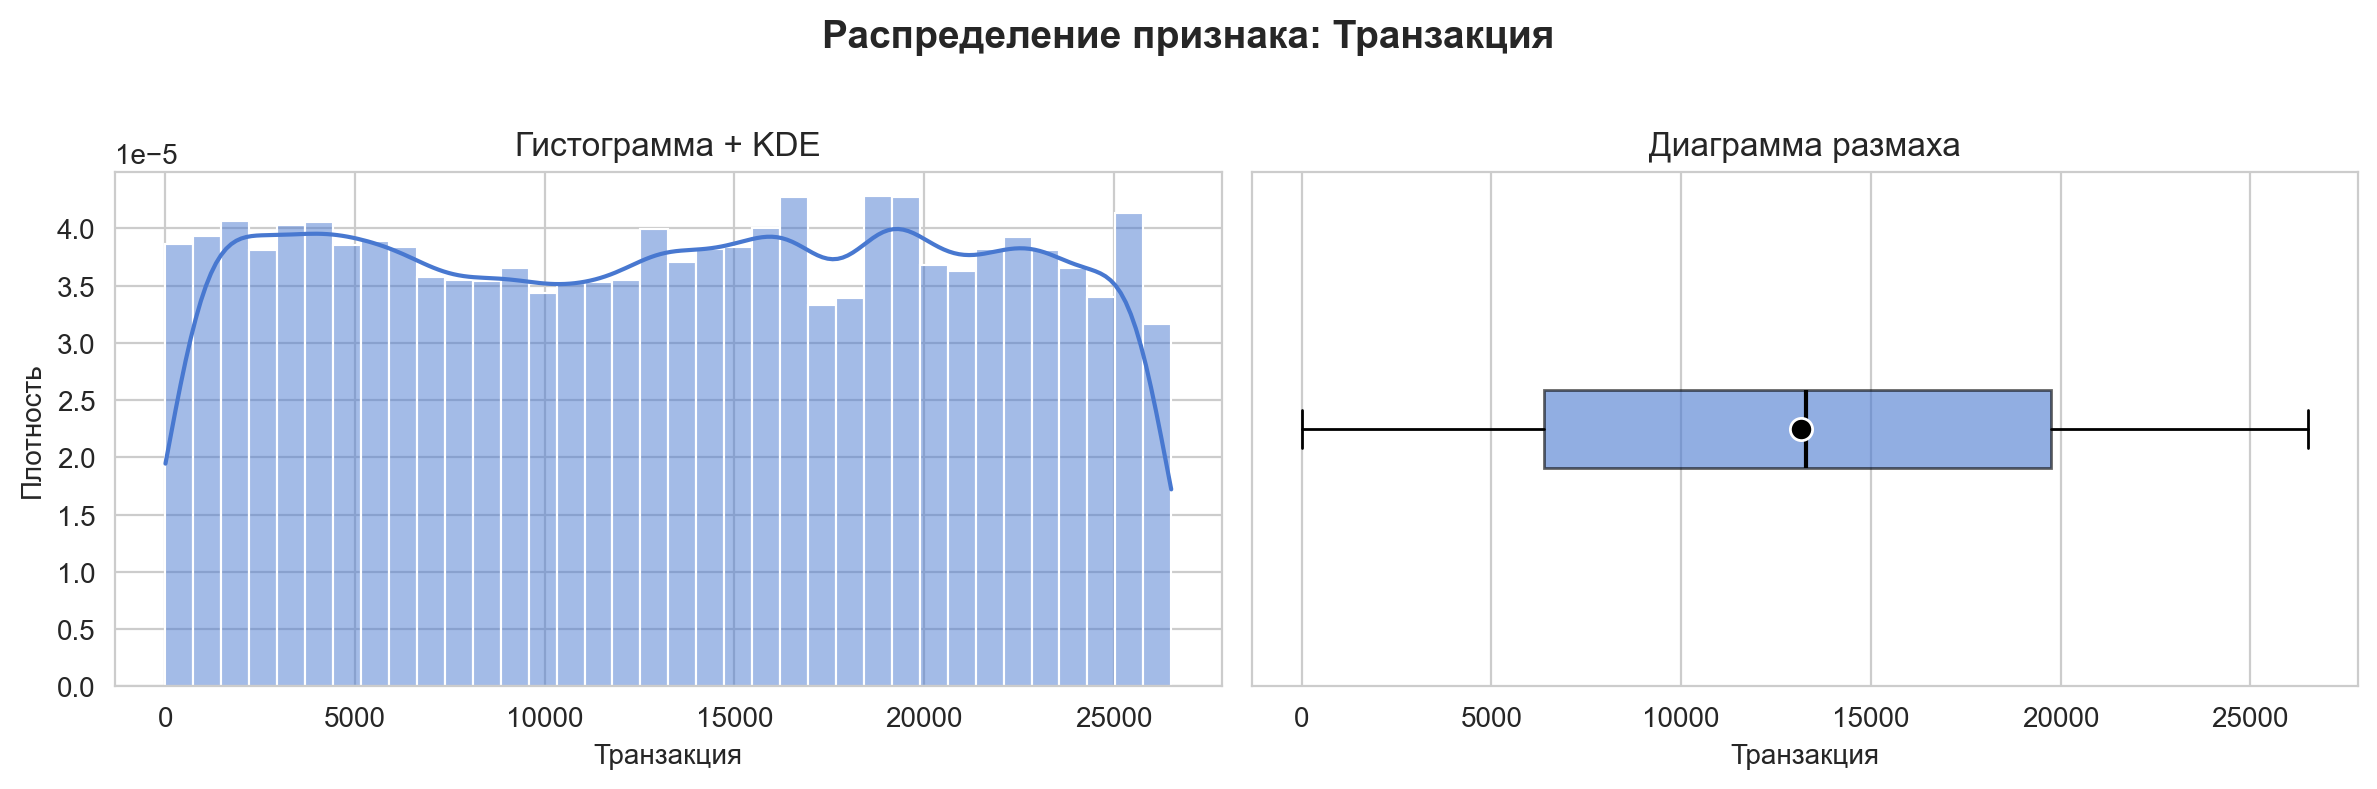

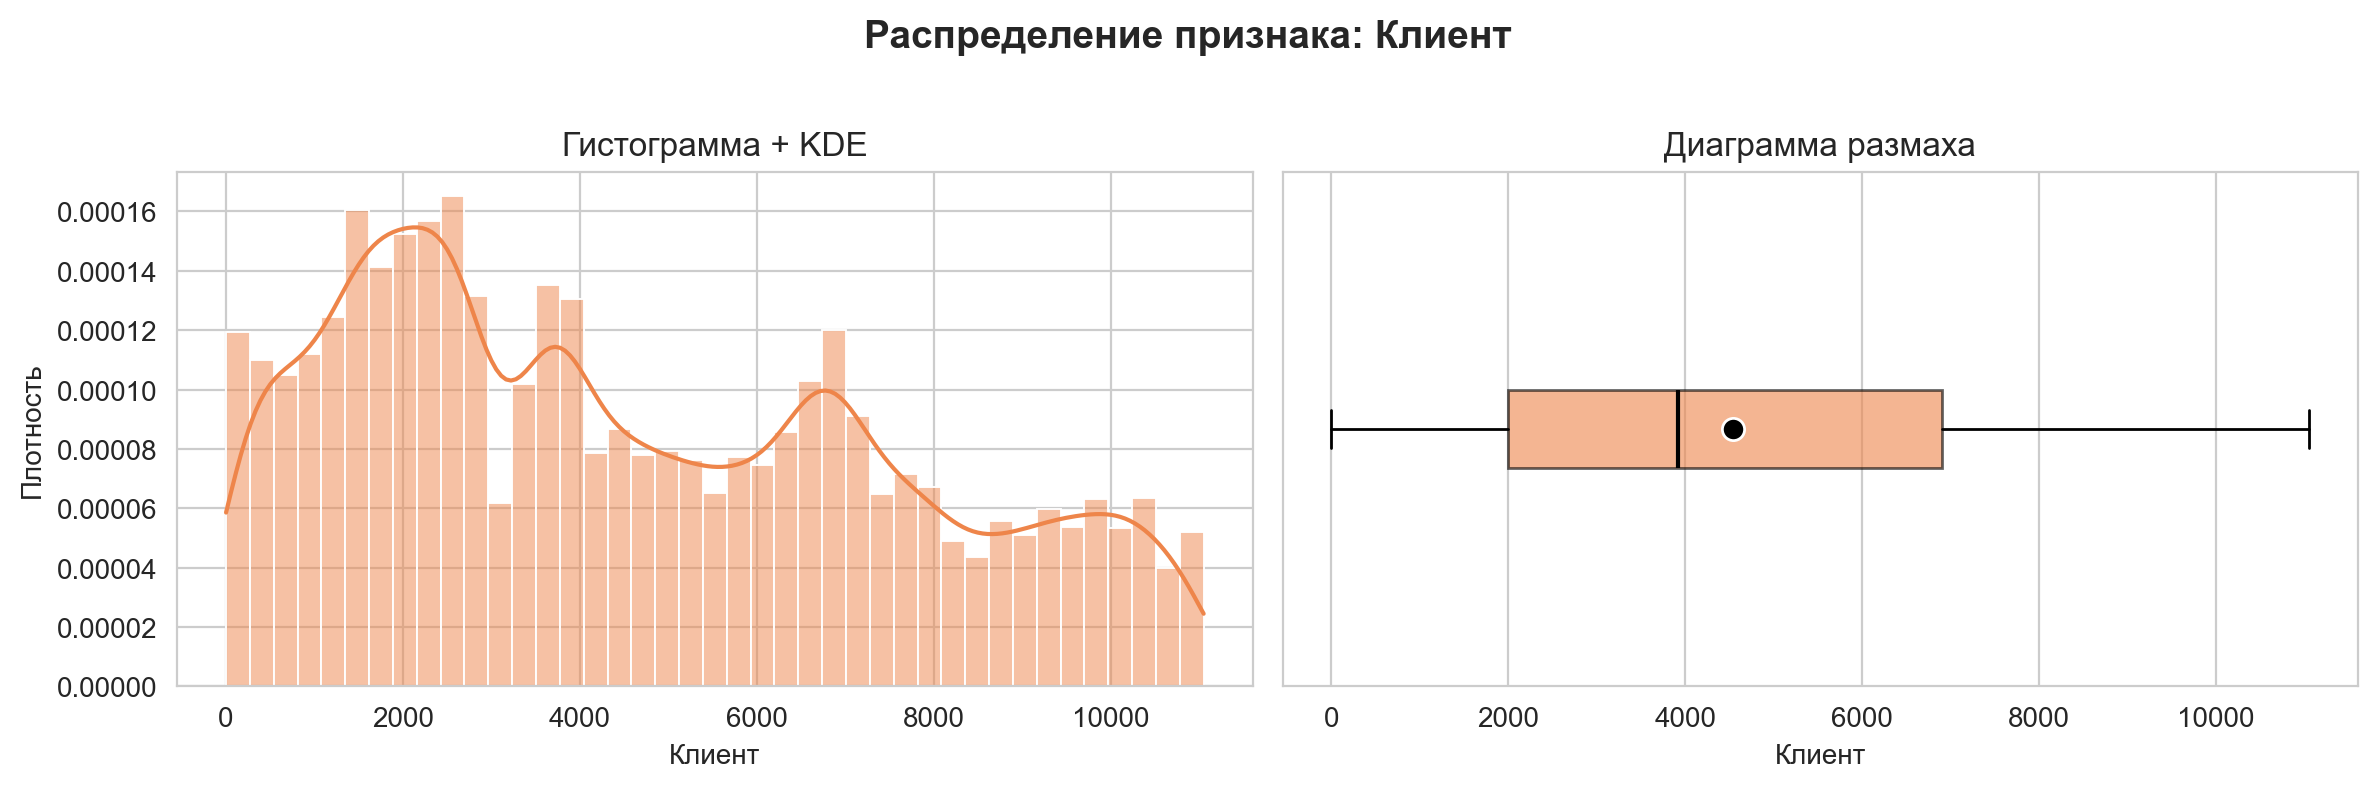

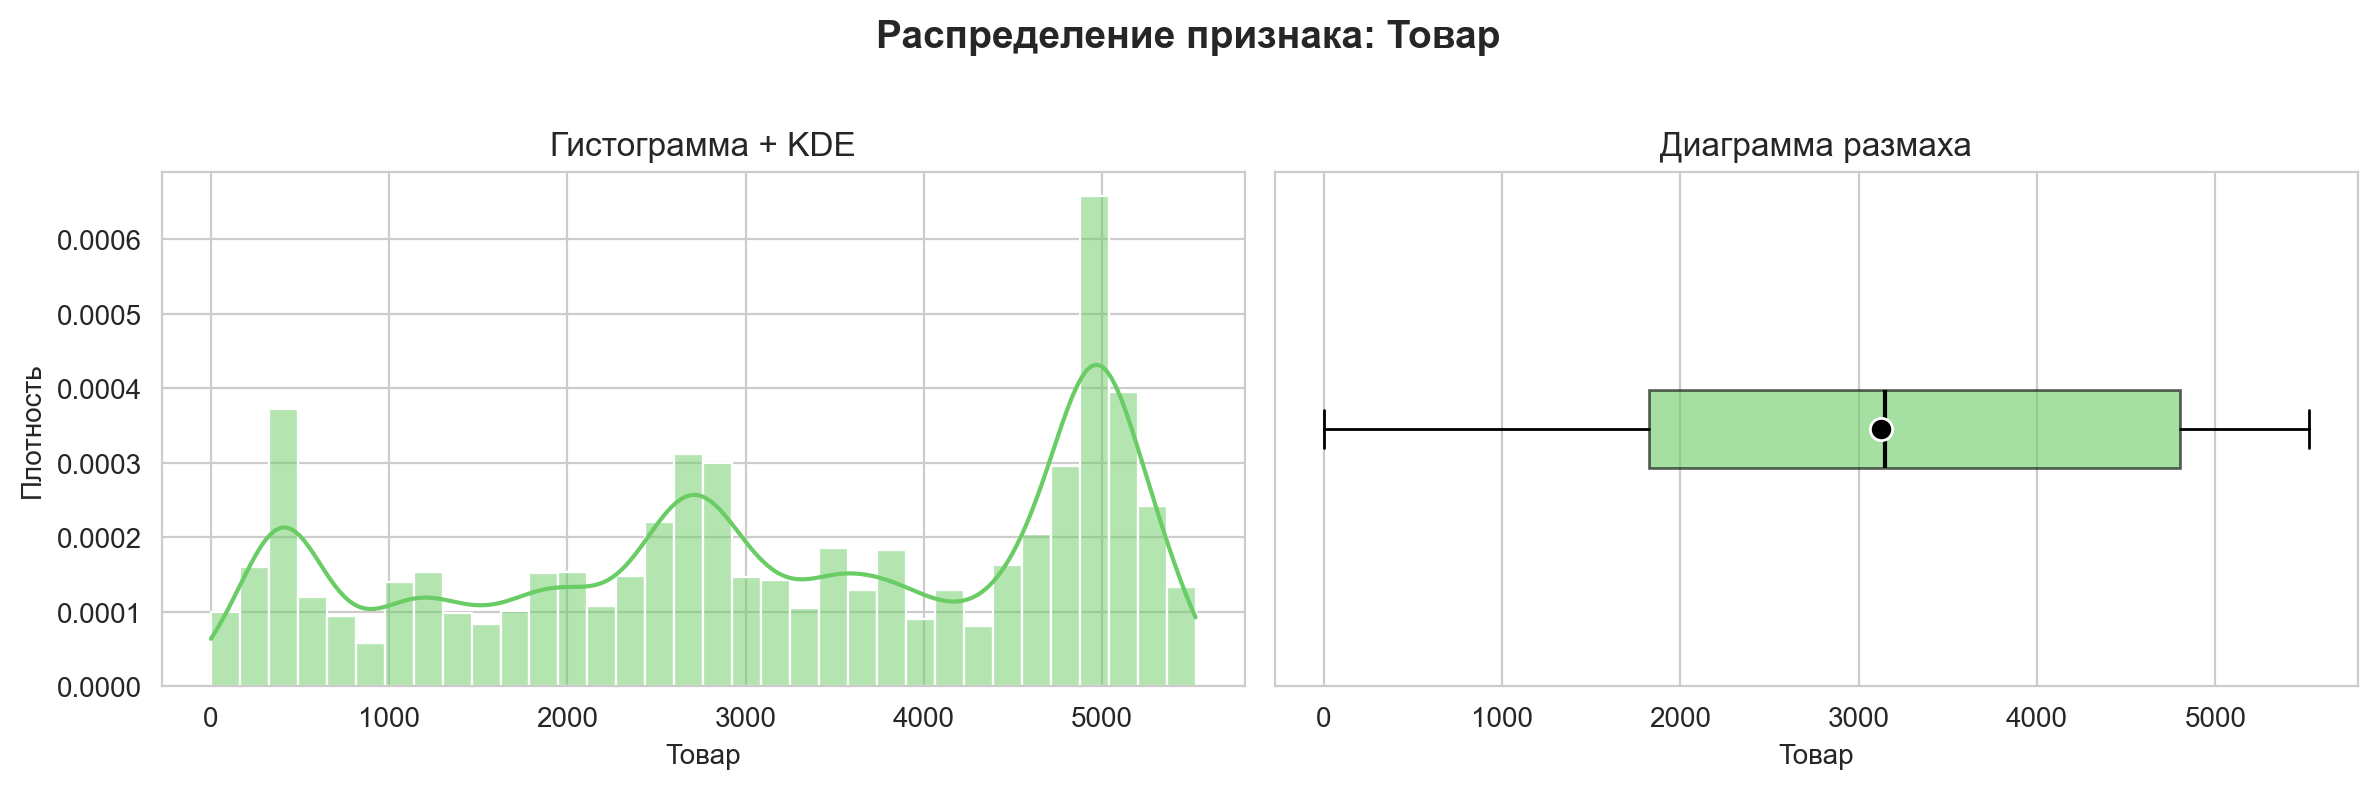

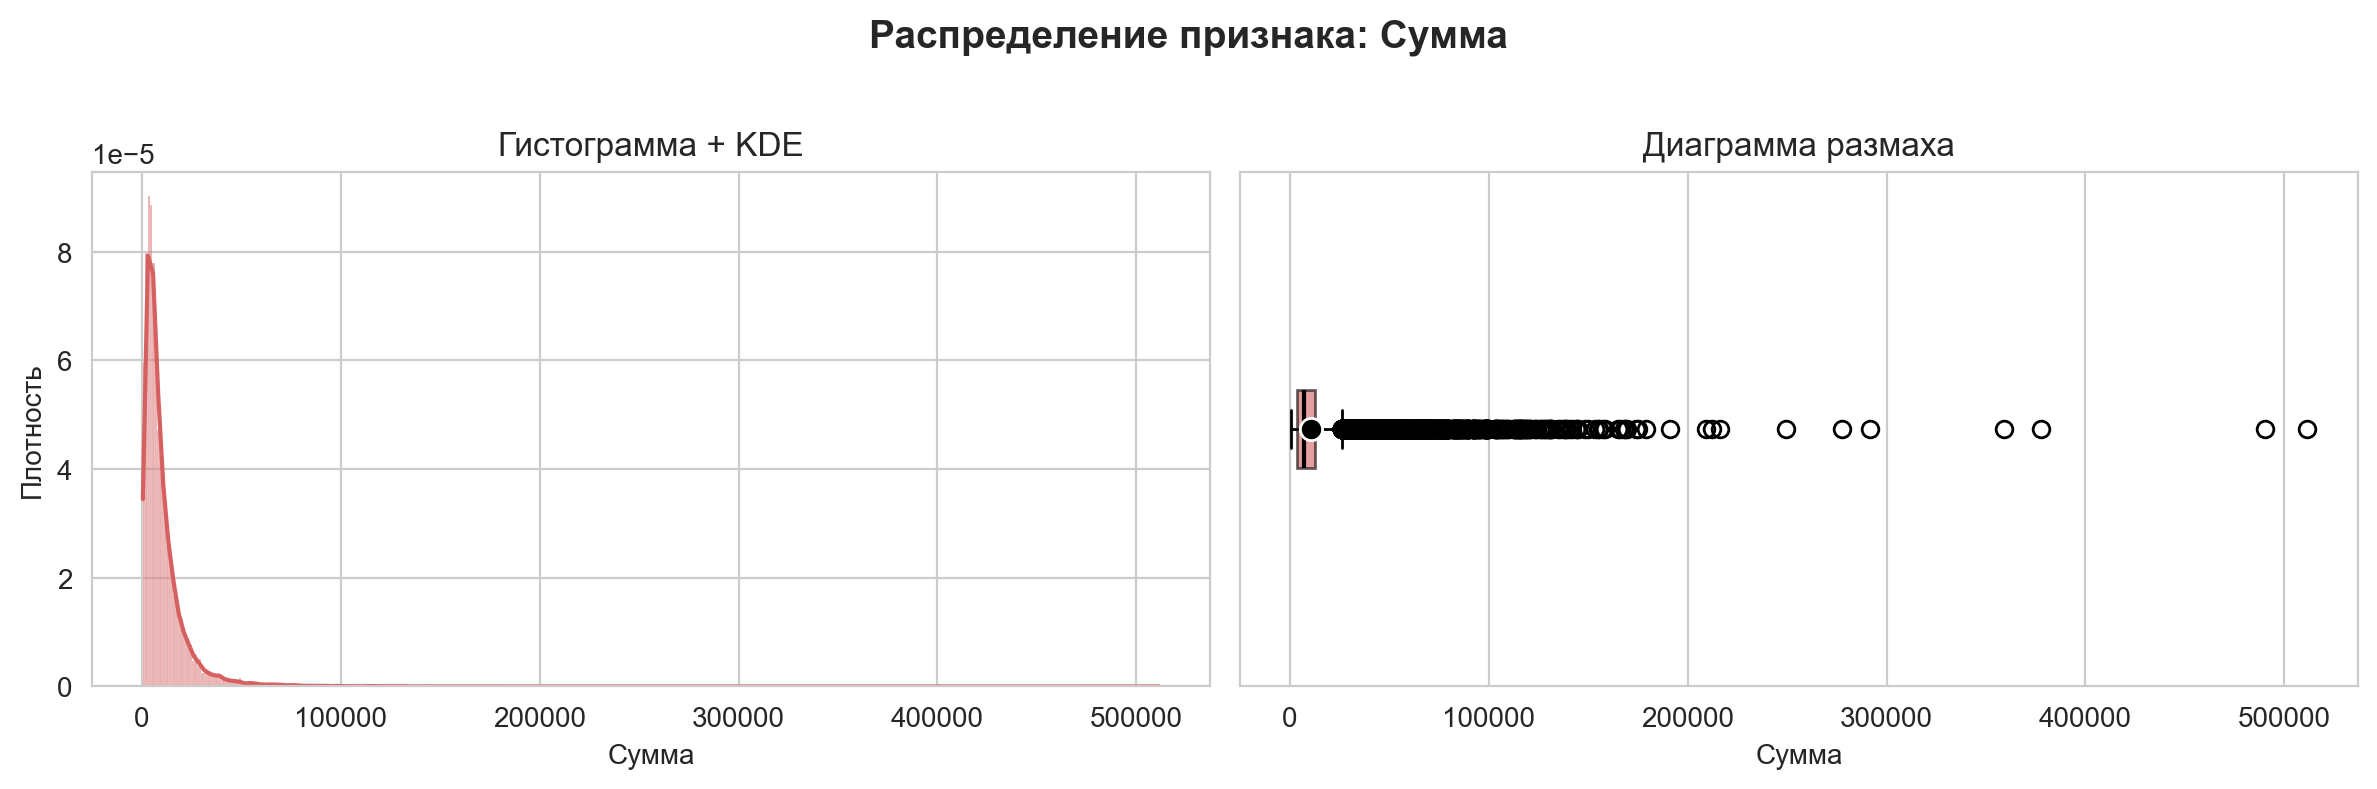

In [15]:
# список имён числовых признаков
numeric_features = ['Транзакция', 'Клиент', 'Товар', 'Сумма']

# цвета для каждого признака
colors = sns.color_palette('muted', len(numeric_features))

for i, col in enumerate(numeric_features):
    color = colors[i]
    data = df[col].dropna()  # исключаем пропуски
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Распределение признака: {col}', fontsize=14, fontweight='bold')
    
    # гистограмма + KDE (распределение частоты значений + оценка плотности плотности случайной величины)
    sns.histplot(data, kde=True, ax=axes[0], color=color, stat='density')
    axes[0].set_title('Гистограмма + KDE')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Плотность')
    
    # boxplot со средним значением
    bp = axes[1].boxplot(
        data,
        vert=False,
        patch_artist=True,
        showmeans=True,
        meanprops={
            'marker': 'o',
            'markerfacecolor': 'black',
            'markeredgecolor': 'white',
            'markersize': 8
        },
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color="black", linewidth=1.5)
    )
    axes[1].set_title('Диаграмма размаха')
    axes[1].set_xlabel(col)
    axes[1].set_yticks([])

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Полученные описательные статистики, подкреплённые визуализаций распределения данных, показывают, что датасет содержит 47 146 транзакций, каждая из которых соответствует одной покупке одного товара (признак  `Количество` везде равен `1`). Это указывает на то, что данные представлены в гранизультированном виде «транзакция–товар», где один чек с несколькими товарами разбит на отдельные строки. Для признаков `Транзакция`, `Клиент` и `Товар` характерна мультимодальность.
<br>Отметим также **уникальность сущностей**: идентификаторы транзакций (от 1 до 26 512) подтверждают, что в среднем одна транзакция в системе отражает одну позицию, а не один чек. Есть 11 050 уникальных клиентов, при этом медианное значение клиентского ID — 3 922, что говорит о неравномерном распределении (возможно, более ранние клиенты более активны). Ассортимент включает 5 523 уникальных товара, при этом большинство покупок приходится на товары с ID до 4 803 (75-й перцентиль).
<br>**Финансовая картина** свидетельствует, что средний чек одной позиции — 10 455, но распределение сильно скошено вправо: медианная сумма (6 910) значительно ниже средней, стандартное отклонение (12 701) превышает среднее значение, максимальная покупка (511 500) является явным выбросом или премиальной транзакцией. Уже 75% покупок стоят до 12 750, а нижняя четверть — до 3 810, что подчёркивает доминирование среднего и средне-низкого ценового сегмента по частоте, но не по выручке.
<br>Следовательно, **данные отражают типичную ритейл-структуру с большим количеством недорогих покупок и редкими, но высокодоходными транзакциями**. Это подтверждает необходимость сегментации клиентов не только по частоте, но и по среднему чеку — особенно с фокусом на выявлении и удержании покупателей в верхнем ценовом сегменте, чьи транзакции, несмотря на низкую частоту, обеспечивают значительную долю выручки.

<a id=3.2.></a>
### Шаг 3.2. Исследование признака `Сумма`

In [16]:
# исходные квантили
desc = df['Сумма'].describe(percentiles=[0.25, 0.50, 0.75, 0.85, 0.90, 1]).astype(int)

# границы
edges = [desc['min'], desc['25%'], desc['50%'], desc['75%'], desc['85%'], desc['90%'], desc['max']]

# убедимся, что границы уникальны и упорядочены
edges = sorted(set(edges))

In [17]:
# определяем бины для pd.cut
cut_bins = edges

# генерируем метки динамически (безопасно и без лишних условий)
labels = [f"{edges[i]} – {edges[i+1]}" for i in range(len(edges) - 1)]

# категоризация (include_lowest=True включает левую границу в первый интервал)
df['Ценовая категория'] = pd.cut(df['Сумма'], bins=cut_bins, labels=labels, include_lowest=True)

In [18]:
# категоризация
df['Ценовая категория'] = pd.cut(df['Сумма'], bins=cut_bins, labels=labels, include_lowest=True)

In [19]:
# агрегация
summary = df.groupby('Ценовая категория', observed=True).agg(Количество_покупок=('Сумма', 'size'), Сумма_покупок=('Сумма', 'sum')).reset_index().rename(columns={'Количество_покупок': 'Количество покупок', 
                                                                                                                                                                  'Сумма_покупок':'Сумма покупок'})

In [20]:
# доля в общей выручке
total = df['Сумма'].sum()
summary['Доля в общей сумме, %'] = (summary['Сумма покупок'] / total * 100).round(3)

In [21]:
# финальная таблица
final_table = summary[['Ценовая категория', 'Количество покупок', 'Сумма покупок', 'Доля в общей сумме, %']]
final_table

,Ценовая категория,Количество покупок,Сумма покупок,"Доля в общей сумме, %"
0,504 – 3810,11799,27313293,5.541
1,3810 – 6910,11778,61878479,12.553
2,6910 – 12750,11823,111601622,22.641
3,12750 – 17450,4780,71422564,14.490
4,17450 – 21750,2276,44422258,9.012
5,21750 – 511500,4690,176283636,35.763


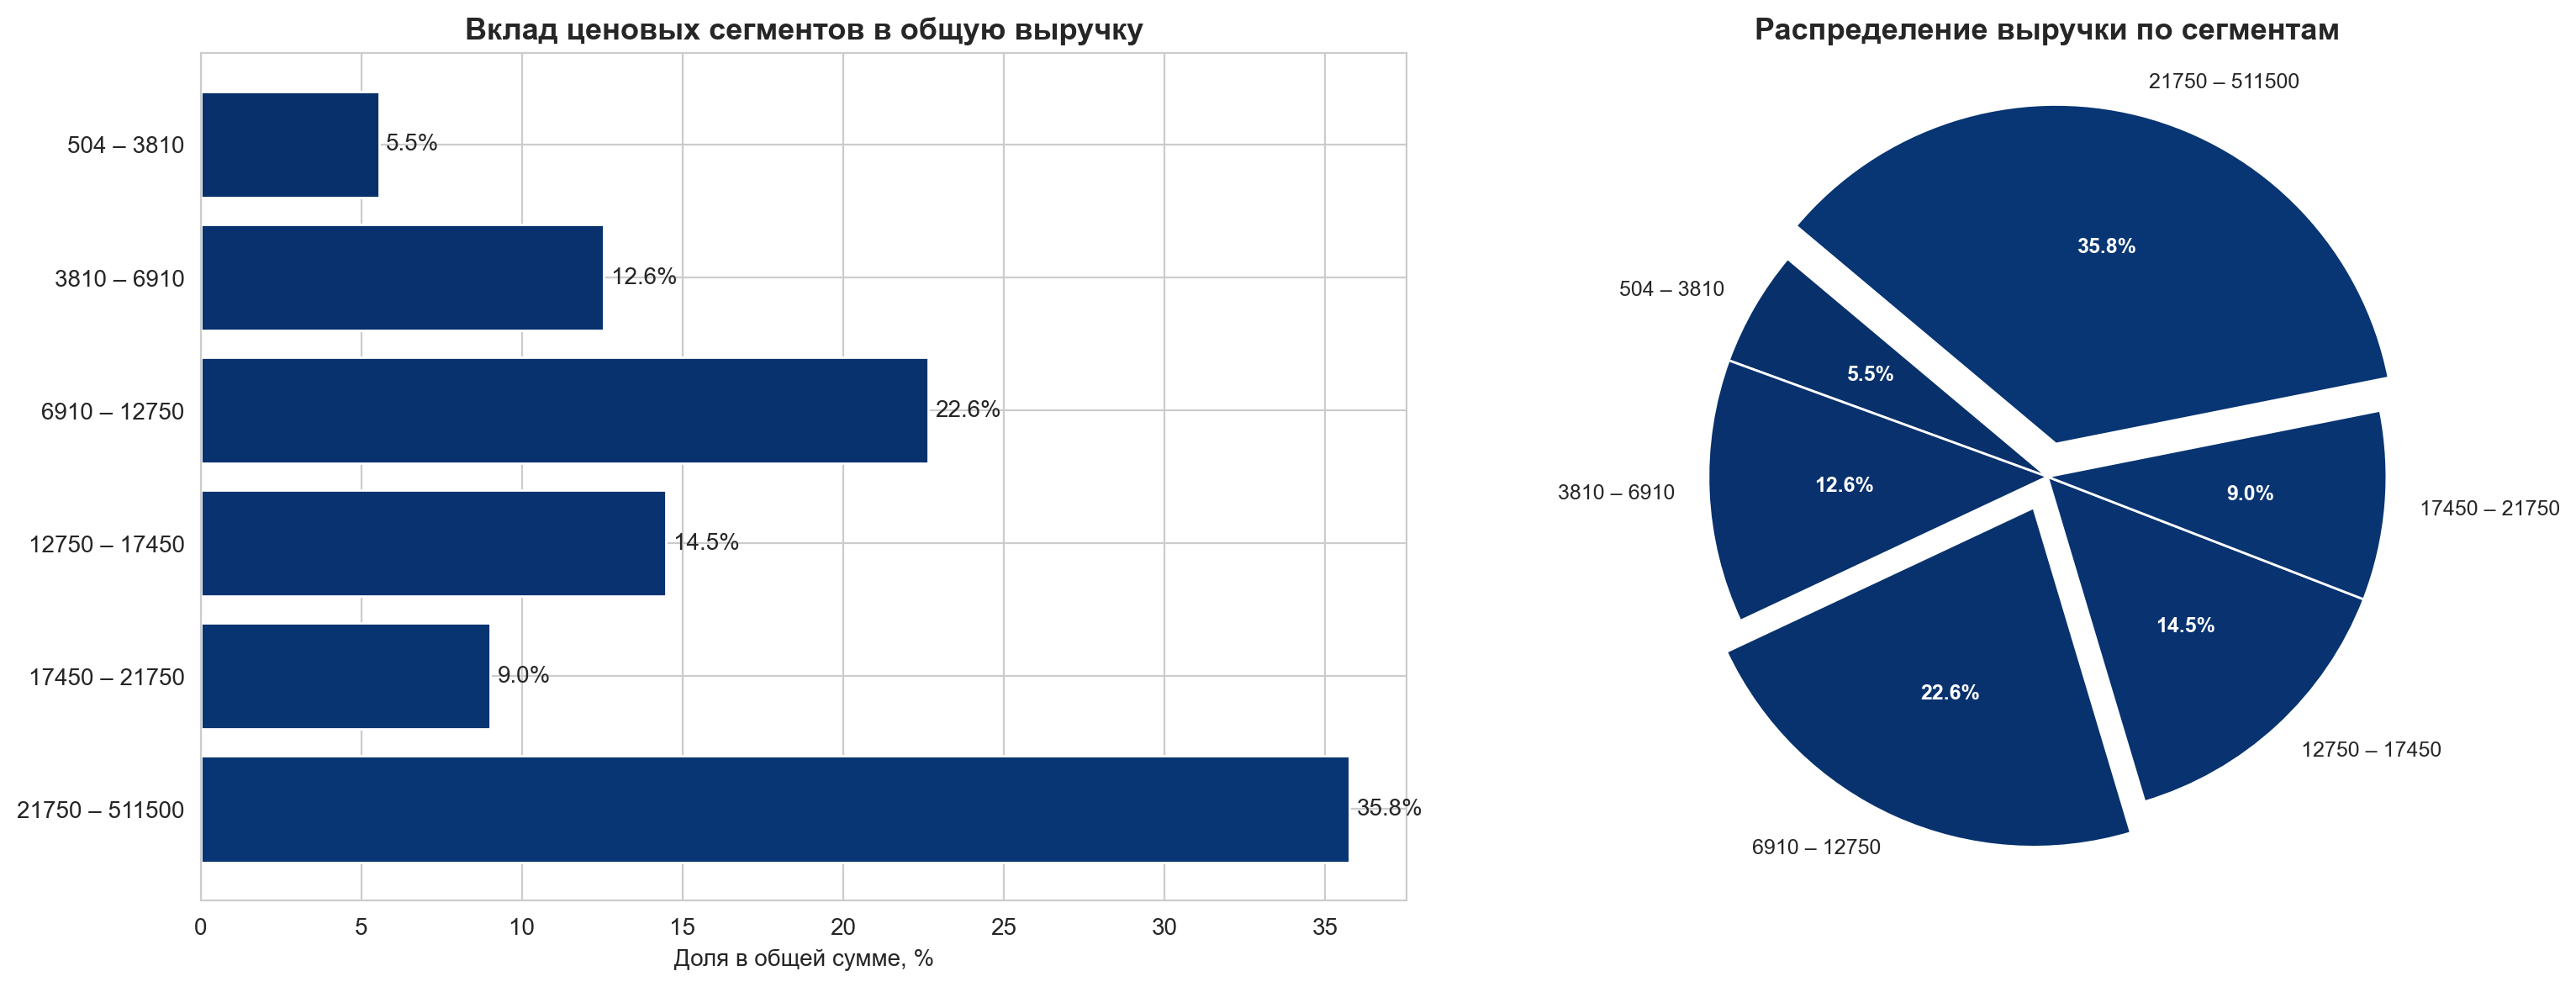

In [22]:
# подготовка данных
labels = final_table['Ценовая категория']
shares = final_table['Доля в общей сумме, %']
counts = final_table['Количество покупок']

# визуализация
colors = plt.cm.Blues_r(range(len(labels)))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# горизонтальный bar chart — доля в общей сумме
bars = axes[0].barh(labels[::-1], shares[::-1], color=colors[::-1])  # переворачиваем для удобства чтения
axes[0].set_xlabel('Доля в общей сумме, %')
axes[0].set_title('Вклад ценовых сегментов в общую выручку', fontsize=13, fontweight='bold')
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)

# круговая диаграмма (pie chart) — с выделением крупных сегментов
# выделим самые значимые сегменты (например, >15%) — в нашем случае это "6 911 – 12 750" и "21 751 – 511 500"
explode = [0.1 if x > 15 else 0 for x in shares]  # выталкиваем сегменты >15%
wedges, texts, autotexts = axes[1].pie(shares, labels=labels, autopct='%1.1f%%', startangle=140, explode=explode, colors=colors, textprops={'fontsize': 9})
axes[1].set_title('Распределение выручки по сегментам', fontsize=13, fontweight='bold')

# улучшим читаемость надписей - сделаем их белым цветом и жирным выделением
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

Анализ распределения выручки по ценовым сегментам выявляет **сильную концентрацию дохода в верхнем ценовом диапазоне**. Наибольший вклад в общую сумму продаж — 35,8% — приходится на покупки в диапазоне от 21 751 до 511 500, хотя на их долю приходится лишь 4 690 транзакций (около 10% от общего числа покупок). Это указывает на высокую ценность «премиальных» покупок: небольшая группа транзакций генерирует более трети выручки. Второй по значимости сегмент — 6 911–12 750, который формирует 22,6% выручки при наибольшем количестве покупок (11 823, или ~25% от общего числа). Это ядро массового спроса. Интересно, что нижний ценовой сегмент (504–3 810), несмотря на большое количество транзакций (11 799, ~25%), вносит вклад всего 5,5% в общую выручку, что подчёркивает его низкую монетизацию.
<br>Также стоит отметить, что все покупки выше 12 750 (сегменты 3–5), составляя менее 18% от общего числа транзакций, генерируют 59,3% всей выручки. Это свидетельствует о том, что лояльность и ценность клиента резко возрастают в верхней части ценовой шкалы.
<br>Для роста выручки ключевое значение имеют стратегии, направленные на увеличение доли высокочековых покупок — через персонализированные предложения, апселл или работу с VIP-клиентами.

Рассмотрим также и временной признак, представленный в датасете после преобразования двумя признаками `Дата_покупки` и `Время_покупки`.

<a id=3.3.></a>
### Шаг 3.3. Исследование признаков `Дата_покупки`, `Время_покупки`

<a id=3.3.1.></a>
#### Шаг 3.3.1. Динамика объёма продаж 

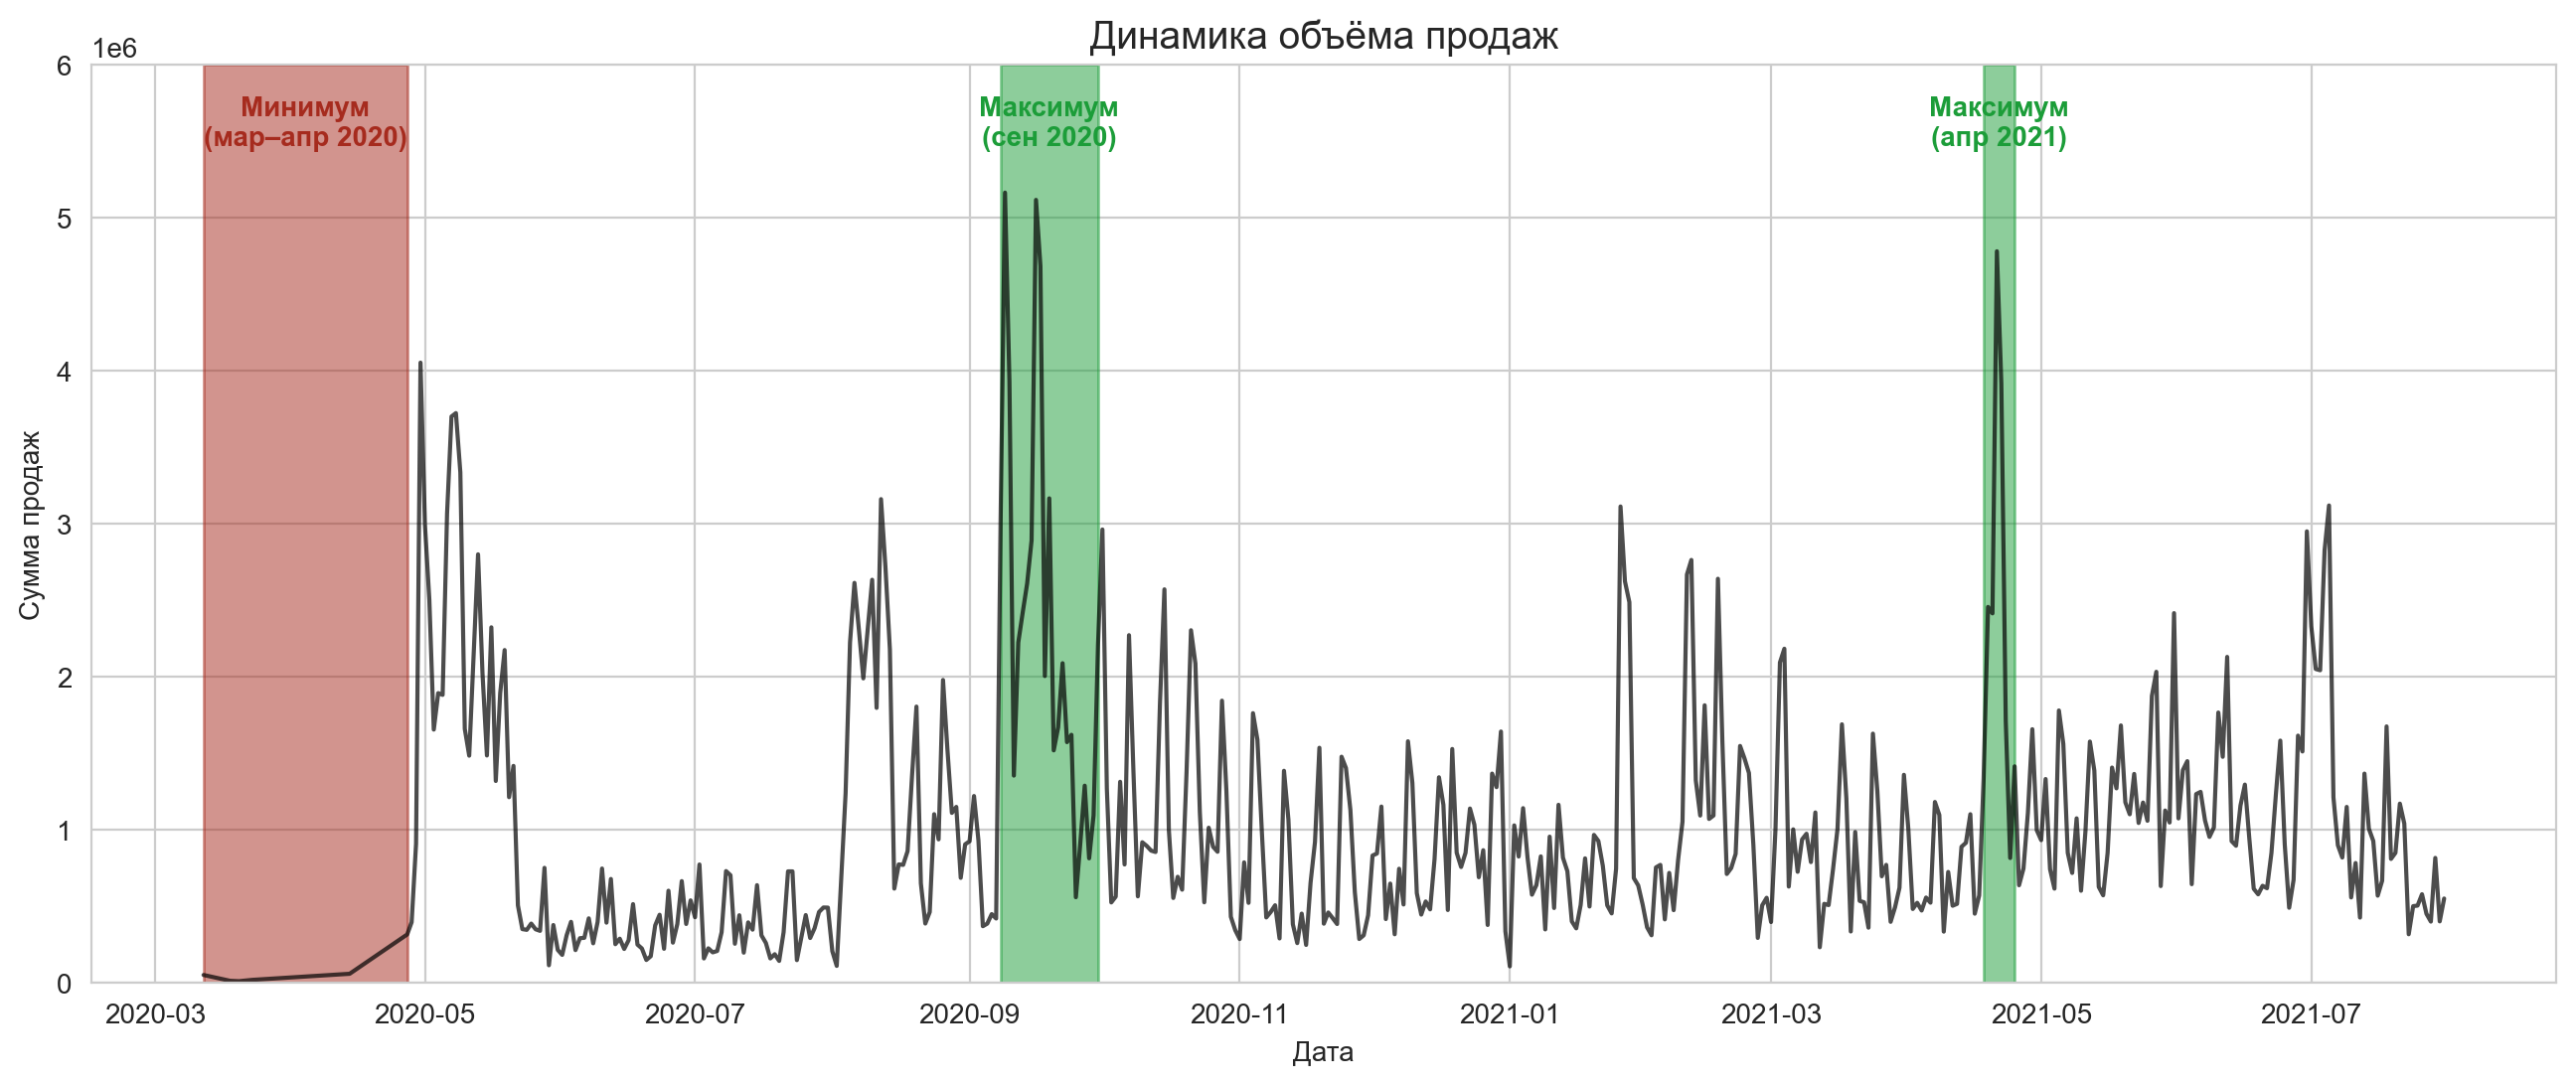

In [23]:
# поиск взаимосвязей: линейный график зависимости суммы продаж от даты
dflineplotsum = df[['Сумма', 'Дата покупки']].groupby('Дата покупки').sum().sort_values('Дата покупки', ascending=True).reset_index()
plt.figure(figsize=(16,6))
sns.lineplot(data=dflineplotsum, x='Дата покупки', y='Сумма', color='black', alpha=0.7)

# выделяем интервалы минимальных и максимальных продаж
min_start_date = pd.to_datetime('2020-03-12')
min_end_date = pd.to_datetime('2020-04-27')
plt.axvspan(min_start_date, min_end_date, color='#A62B1E', alpha=0.5)

max1_start_date = pd.to_datetime('2020-09-08')
max1_end_date = pd.to_datetime('2020-09-30')
plt.axvspan(max1_start_date, max1_end_date, color='#1C9D39', alpha=0.5)

max2_start_date = pd.to_datetime('2021-04-18')
max2_end_date = pd.to_datetime('2021-04-25')
plt.axvspan(max2_start_date, max2_end_date, color='#1C9D39', alpha=0.5)

# подписи на графике
plt.text(min_start_date + (min_end_date - min_start_date) / 2, 5_800_000, 'Минимум\n(мар–апр 2020)', 
         ha='center', va='top', color='#A62B1E', fontweight='bold', fontsize=10)
plt.text(max1_start_date + (max1_end_date - max1_start_date) / 2, 5_800_000, 'Максимум\n(сен 2020)', 
         ha='center', va='top', color='#1C9D39', fontweight='bold', fontsize=10)
plt.text(max2_start_date + (max2_end_date - max2_start_date) / 2, 5_800_000, 'Максимум\n(апр 2021)', 
         ha='center', va='top', color='#1C9D39', fontweight='bold', fontsize=10)

plt.ylim(0, 6_000_000)
plt.title('Динамика объёма продаж', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.show()

**Вывод:** линейный график зависимости частоты покупок от даты показывает нам динамику развития деятельности магазина. С апреля по октябрь 2020 года отмечается серьёзный рост продаж. С ноября 2020 года по апрель 2021 года длится период стабильности частоты покупок с последующим незначительным ростом вплоть до мая 2021 года. С этого момента происходит обрушение показателя до стартовых значений. С октября 2021 года по январь 2022 рост показателя частоты покупок во времени выражен слабо, прогноз о положительной динамике маловероятен.

<a id=3.3.2.></a>
#### Шаг 3.3.2. Режим работы объекта торговли

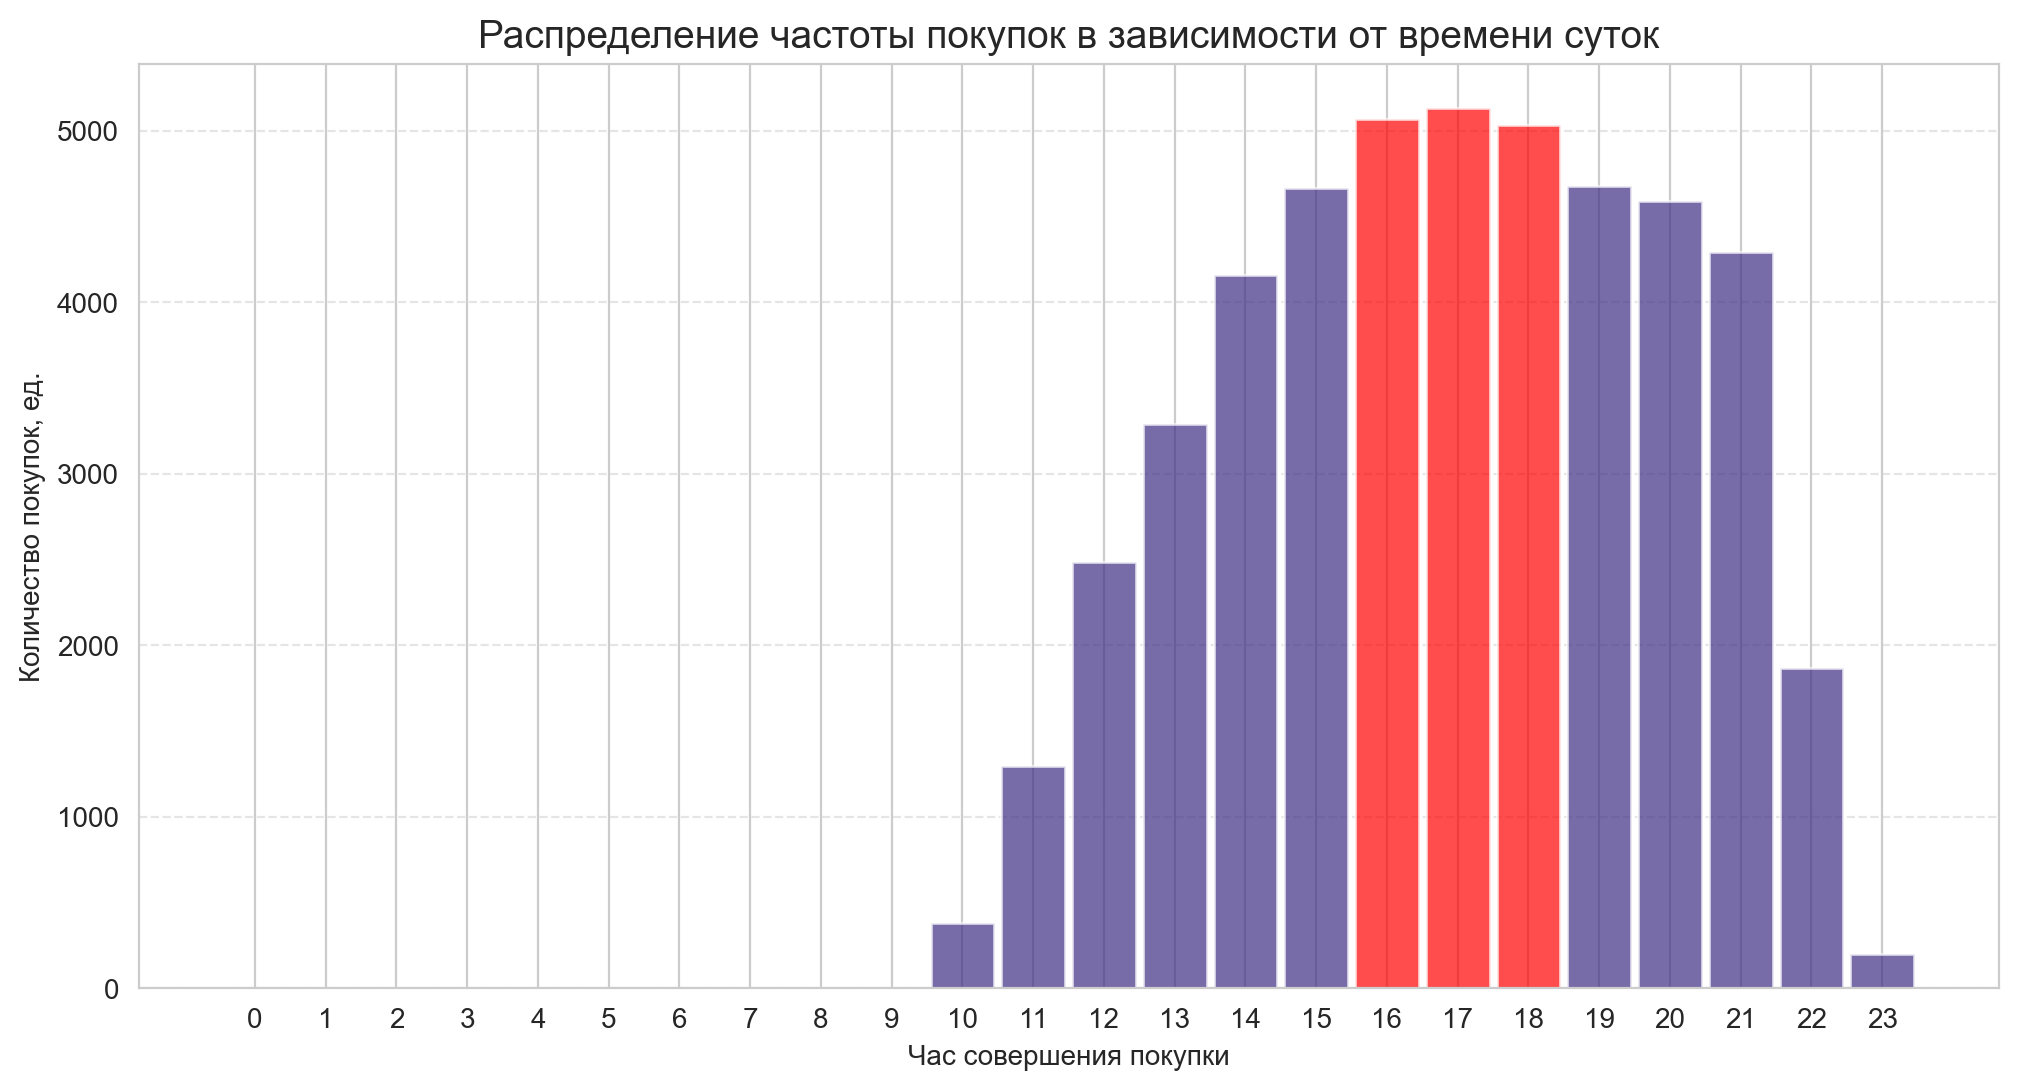

In [24]:
# гистограмма распределения частоты покупок в зависимости от времени суток
df['Время покупки'] = df['Время покупки'].apply(lambda t: t.hour)

# подсчитываем количество покупок по каждому часу (от 0 до 23)
counts, _ = np.histogram(df['Время покупки'], bins=np.arange(25))  # 24 bins: 0–23

# определяем цвета: по умолчанию '#3E2D84', но 17, 18, 19 — красные пиковые часы нагрузки
colors = ['#3E2D84'] * 24
for hour in [16, 17, 18]:
    colors[hour] = 'red'

# визуализация: столбчатая диаграмма
plt.figure(figsize=(12, 6))
plt.bar(range(24), counts, color=colors, alpha=0.7, edgecolor='white', width=0.9)

plt.xticks(range(0, 24))
plt.title('Распределение частоты покупок в зависимости от времени суток', fontsize=14)
plt.xlabel('Час совершения покупки')
plt.ylabel('Количество покупок, ед.')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Вывод:** на основании полученных данных мы можем сделать некоторые предположения о графике и режиме работы данного магазина.

График работы магазина является нормированным: магазин был открыт для покупателей с 10 утра до 24 часов ночи. Покупки совершались с 11:00:00 1 мая 2020 года, последняя транзакция зафиксирована 22:28:00 12 июля 2021 года. Пиковая нагрузка выражена явно, и пребывает в границах между 16 и 18 часами вечера включительно. Минимальный поток клиентов - после 21 часа.

В соответствии с производственным календарём на 2020 и 2021 годы соответственно, магазин работал без выходных дней. Следовательно, для сотрудников установлен скользящий график работы с выходными днями на выбор самого сотрудника. Учитывая неблагополучную эпидемиологическую обстановку, возникшую в конце 2019 года, и вызванную распространением новой коронавирусной инфекции SARS-CoV-2019, магазин работал без ограничений и был доступен для покупателей даже в период всеобщего локдауна. 

<a id=3.4.></a>
### Шаг 3.4. Исследование признака `Товар`

<a id=3.4.1.></a>
#### Шаг 3.4.1. Топ-10 самых прибыльных товаров, их ценовые категории и их доля выручки

In [25]:
# агрегация по товарам: сумма и количество
itempopsum = (df[['Товар', 'Количество', 'Сумма']].groupby('Товар').sum().sort_values('Сумма', ascending=False).head(10).reset_index())

# получаем соответствие Товар -> Ценовая категория (берем самую частую категорию для товара)
product_to_group = df.groupby('Товар')['Ценовая категория'].agg(lambda x: x.mode()[0]).reset_index()

# присоединяем ценовую категорию
itempopsum = itempopsum.merge(product_to_group, on='Товар', how='left')

# порядок столбцов для удобства
itempopsum = itempopsum[['Товар', 'Количество', 'Сумма', 'Ценовая категория']]
itempopsum.head(10)

,Товар,Количество,Сумма,Ценовая категория
0,3060,156,7114335,21750 – 511500
1,4757,281,6684263,21750 – 511500
2,4944,725,5092296,6910 – 12750
3,3487,435,4566215,6910 – 12750
4,2430,94,3805181,21750 – 511500
5,5019,399,3056353,3810 – 6910
6,4803,147,2775456,21750 – 511500
7,4692,39,2522075,21750 – 511500
8,1789,143,2509567,12750 – 17450
9,5064,423,2394337,3810 – 6910


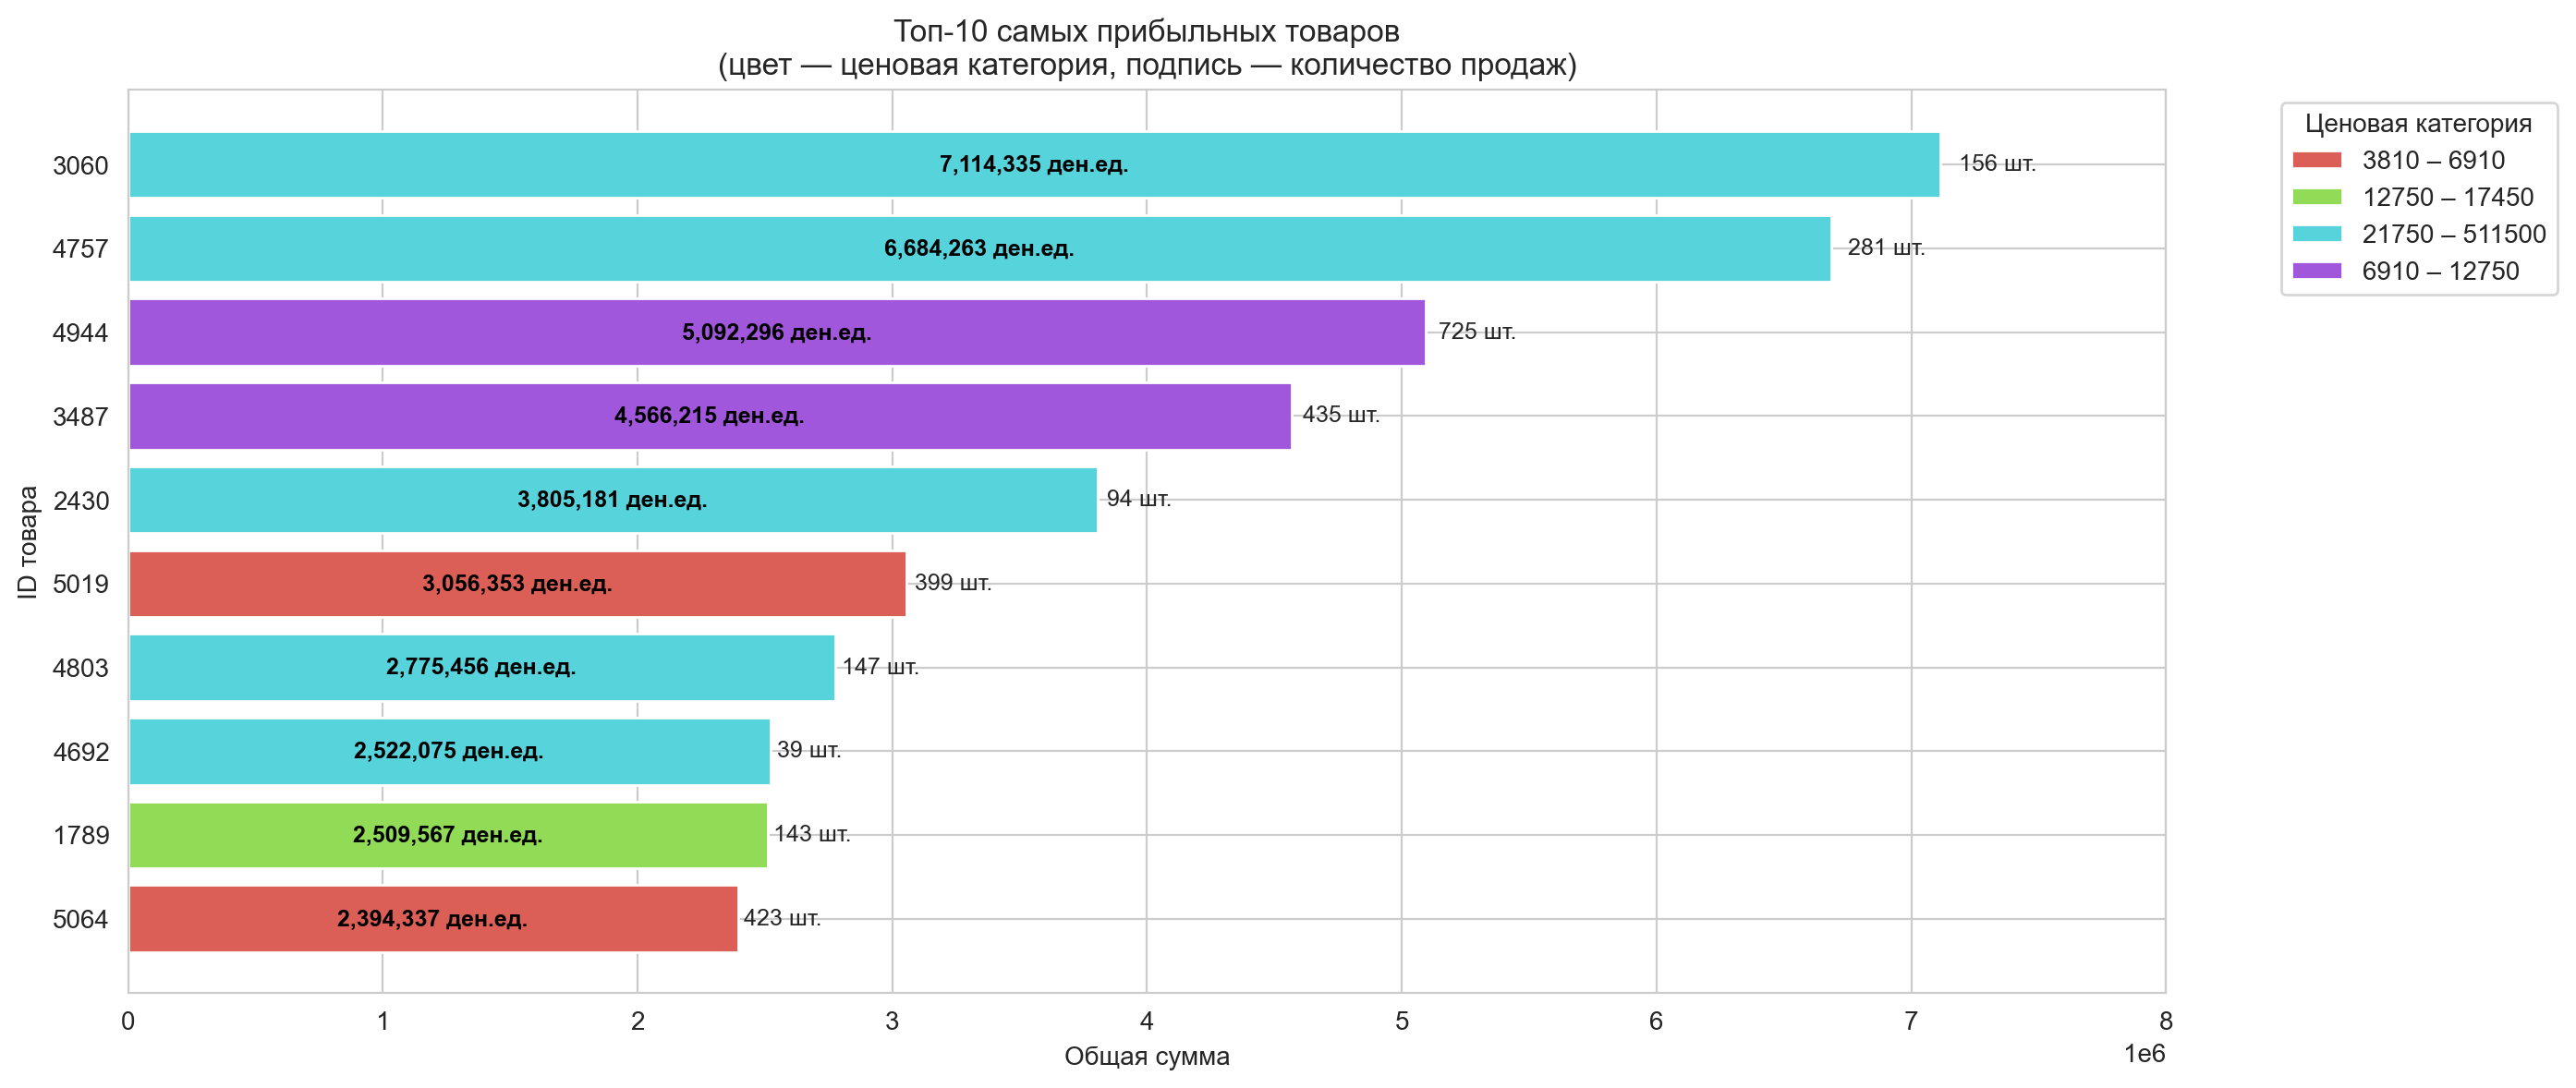

In [26]:
# для корректного порядка на горизонтальной диаграмме
top10 = itempopsum.sort_values('Сумма', ascending=True)

# определяем палитру по каждой группе
group_colors = sns.color_palette('hls', n_colors=top10['Ценовая категория'].nunique())
group_map = {group: color for group, color in zip(top10['Ценовая категория'].unique(), group_colors)}

# присваиваем цвет каждому товару
colors = top10['Ценовая категория'].map(group_map)

# визуализация: горизонтальная столбчатая диаграмма
plt.figure(figsize=(12, 6))
bars = plt.barh(top10['Товар'].astype(str), top10['Сумма'], color=colors, edgecolor='white')

# аннотации с количеством проданного товара, шт.
for i, (bar, qty) in enumerate(zip(bars, top10['Количество'])):
    plt.text(bar.get_width() + bar.get_width() * 0.01, bar.get_y() + bar.get_height()/2,
             f'{qty} шт.', va='center', fontsize=9)

# аннотации по сумме продаж
for bar, total in zip(bars, top10['Сумма']):
    plt.text(bar.get_width() / 2, 
             bar.get_y() + bar.get_height()/2,
             f'{total:,} ден.ед.', 
             va='center', ha='center', 
             fontsize=9, color='black', fontweight='bold')

plt.xlabel('Общая сумма')
plt.ylabel('ID товара')
plt.title('Топ-10 самых прибыльных товаров\n(цвет — ценовая категория, подпись — количество продаж)')
plt.tight_layout()

# легенда по ценовым категориям
legend_elements = [Patch(facecolor=group_map[group], label=group) for group in group_map]
plt.legend(handles=legend_elements, title='Ценовая категория', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 8_000_000)
plt.show()

In [27]:
# доля топ-10 прибыльных товаров в общей выручке# агрегация по товарам: сумма и количество
itempopsum = (df[['Товар', 'Количество', 'Сумма']]
              .groupby('Товар')
              .sum()
              .sort_values('Сумма', ascending=False)
              .head(10)
              .reset_index())

# получаем соответствие Товар -> Ценовая категория
product_to_group = df[['Товар', 'Ценовая категория']].drop_duplicates(subset='Товар')

# присоединяем ценовую категорию
itempopsum = itempopsum.merge(product_to_group, on='Товар', how='left')

# порядок столбцов для удобства
itempopsum = itempopsum[['Товар', 'Количество', 'Сумма', 'Ценовая категория']]

In [28]:
# расчёт доли топ-10 прибыльных товаров в общей выручке
total_revenue = df['Сумма'].sum()
top10_revenue = itempopsum['Сумма'].sum()
top10_share = top10_revenue / total_revenue

print(f"Доля топ-10 товаров в общей выручке: {top10_share:.2%}")

# добавляем столбец с долей каждого из топ-10 товаров в общей выручке
itempopsum['Доля в общей выручке, %'] = (itempopsum['Сумма'] / total_revenue * 100).round(2)
itempopsum.head(10) 

Доля топ-10 товаров в общей выручке: 8.22%


,Товар,Количество,Сумма,Ценовая категория,"Доля в общей выручке, %"
0,3060,156,7114335,17450 – 21750,1.44
1,4757,281,6684263,12750 – 17450,1.36
2,4944,725,5092296,3810 – 6910,1.03
3,3487,435,4566215,6910 – 12750,0.93
4,2430,94,3805181,21750 – 511500,0.77
5,5019,399,3056353,6910 – 12750,0.62
6,4803,147,2775456,3810 – 6910,0.56
7,4692,39,2522075,21750 – 511500,0.51
8,1789,143,2509567,21750 – 511500,0.51
9,5064,423,2394337,3810 – 6910,0.49


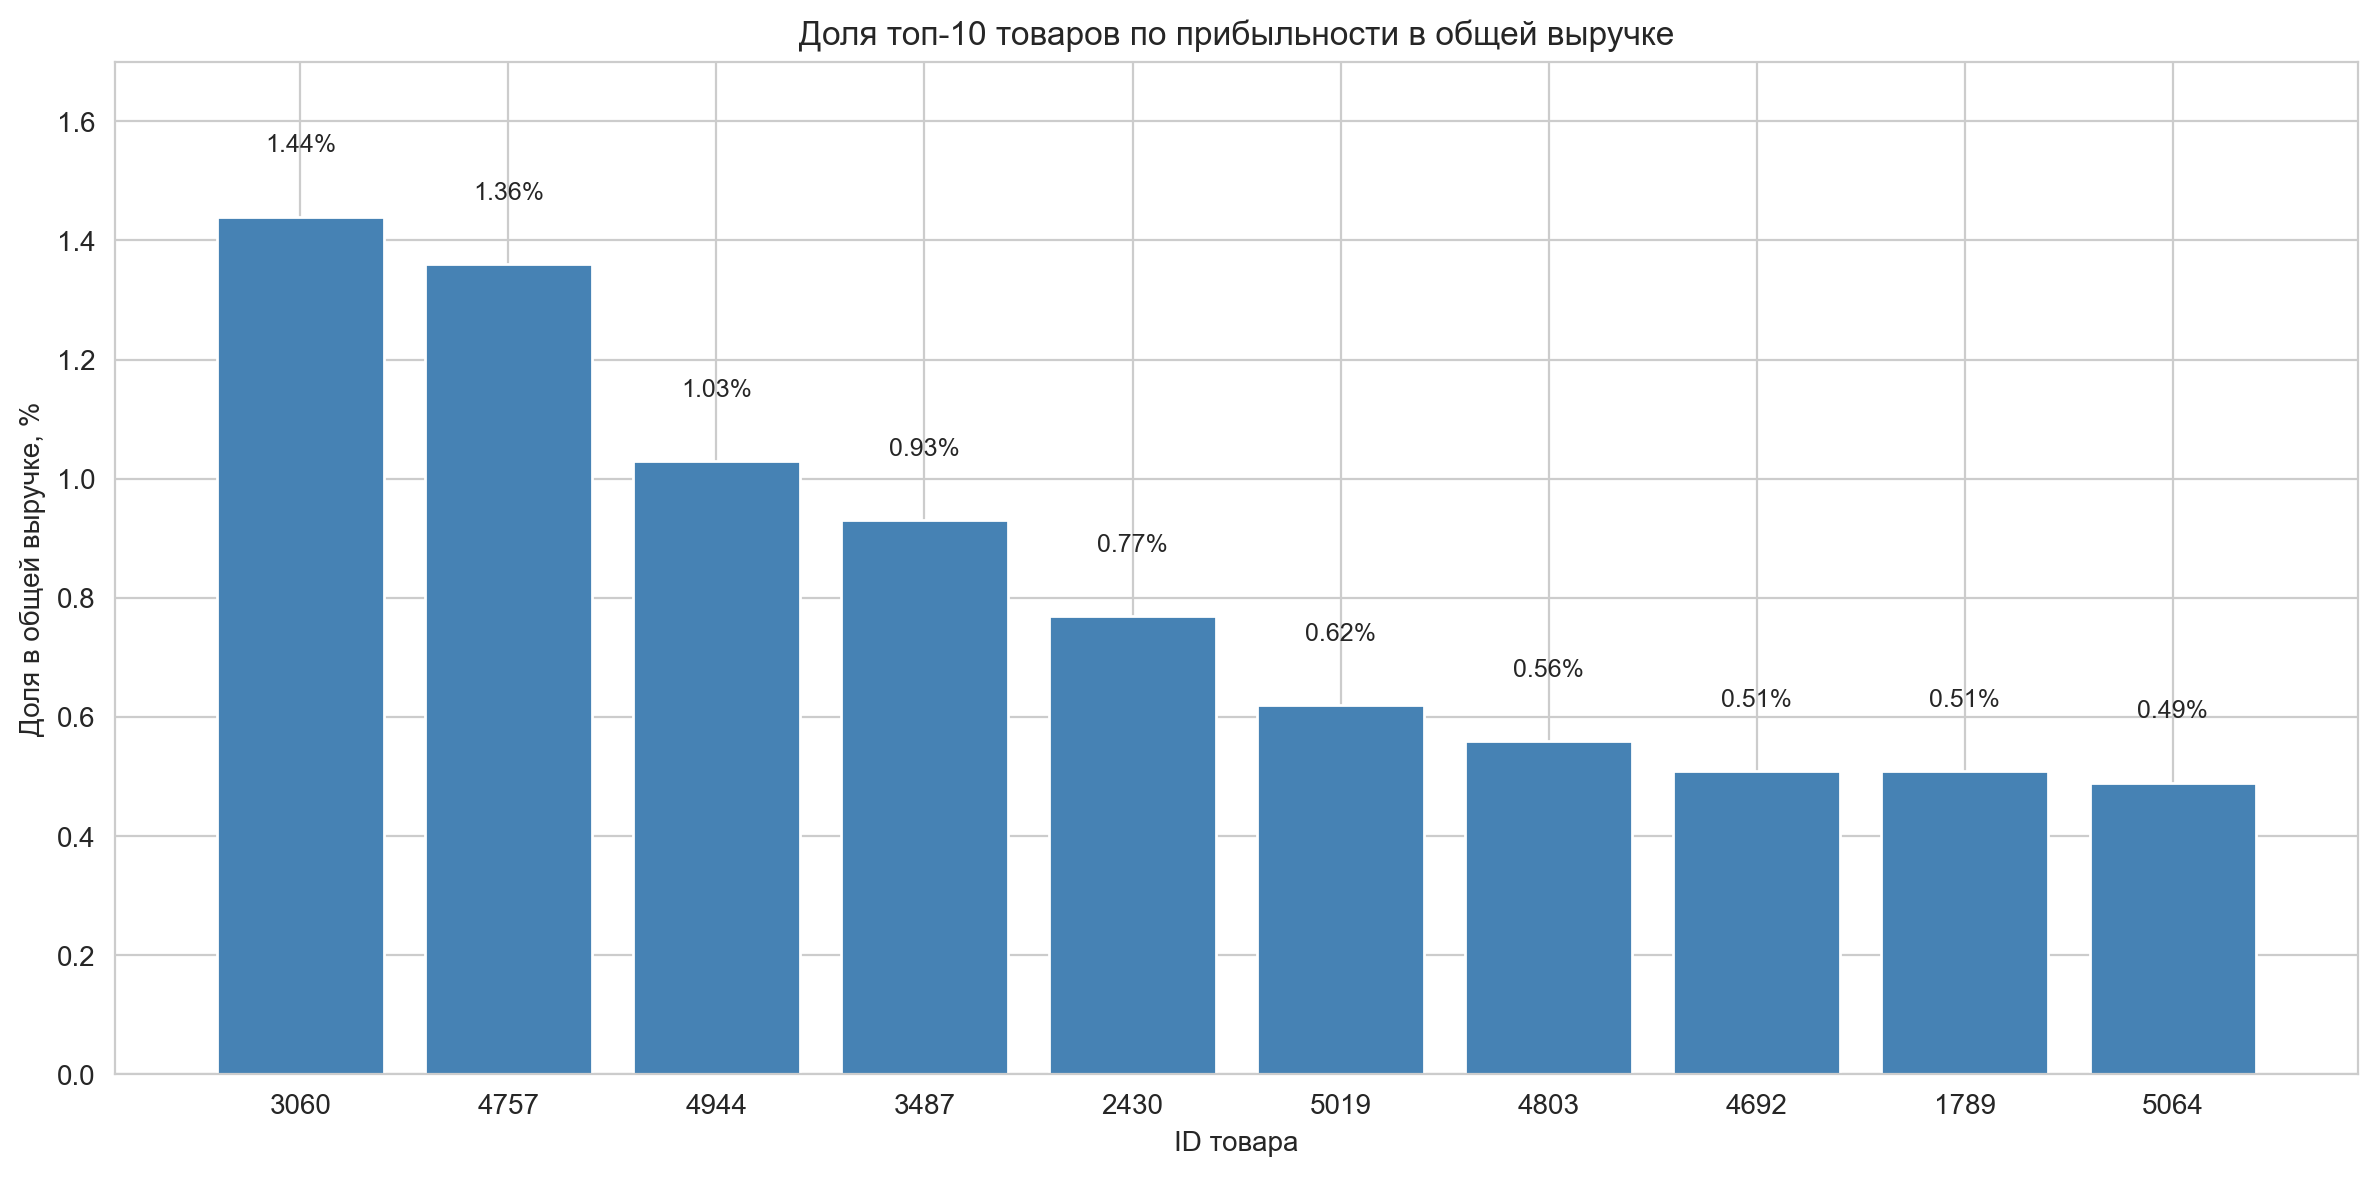

In [29]:
# визуализация доли топ-10 прибыльных товаров в общей выручке
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(itempopsum)), itempopsum['Доля в общей выручке, %'], color='steelblue')

# аннотации
for bar, share in zip(bars, itempopsum['Доля в общей выручке, %']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{share}%', 
             ha='center', va='bottom', fontsize=9)
    
plt.ylim(0, 1.7)
plt.xticks(range(len(itempopsum)), itempopsum['Товар'], rotation=0, ha='center')
plt.xlabel('ID товара')
plt.ylabel('Доля в общей выручке, %')
plt.title('Доля топ-10 товаров по прибыльности в общей выручке')
plt.tight_layout()
plt.show()

**Выводы:**
<br>**1. Лидеры по выручке**
<br>Самым прибыльным товаром является `ID 3060` с общей выручкой 7,1 млн. ден.ед., несмотря на относительно небольшое количество продаж (156 шт.). Он относится к высокой ценовой категории `17 451 – 21 750`, что указывает на высокую стоимость единицы (~45,6 тыс. ден.ед.). Второе место занимает товар `ID 4757` (6,7 млн ден.ед.), также из дорогого сегмента (`12 751 – 17 450`), но с б**о́**льшим объёмом продаж (281 шт.).
<br>**2. Роль объёма vs цены**
<br>Товар `ID 4944` (категория `3 811 – 6 910`) демонстрирует высокую прибыльность (5,1 млн руб.) за счёт массовых продаж (725 шт.), несмотря на низкую ценовую категорию. Это говорит о его популярности среди широкой аудитории.
Аналогично, товары `ID 3487`, `ID 5019` и `ID 5064` из среднего и нижнего сегментов цен также входят в топ-10 благодаря значительному количеству продаж (от 399 до 435 шт.).
<br>**3. Наличие премиальных позиций**
<br>В топ-10 присутствуют товары из самой высокой ценовой группы (`21 751 – 511 500`): `ID 2430`, `ID 4692`, `ID 1789`. Несмотря на низкие объёмы (39–94 шт.), они генерируют существенную выручку (2,5–3,8 млн ден.ед.), что подчёркивает наличие спроса на премиальные товары.
<br>**4. Сбалансированность ассортимента**
<br>Топ-10 включает товары из всех ценовых сегментов, что говорит о сбалансированной товарной матрице: компания успешно продаёт как массовые недорогие товары, так и дорогие, обеспечивающие высокую маржинальность.
<br>Следовательно, для устойчивой выручки бизнес опирается как на высокомаржинальные премиальные товары, так и на высокочастотные позиции массового спроса. Это позволяет охватывать разные сегменты клиентов и снижать риски, связанные с зависимостью от одной ценовой категории.

<a id=3.4.2.></a>
#### Шаг 3.4.2. Распределение всех товаров и топ-10 товаров по прибыльности по категориям покупательской активности во времени

Необходимо понять, есть ли у определённых товаров «пиковое» время покупки.

In [30]:
# считаем среднее время покупки по каждому товару
avg_time_by_item = (df.groupby('Товар')['Время покупки'].mean().reset_index().rename(columns={'Время покупки': 'Среднее время покупки'}))
avg_time_by_item['Среднее время покупки'] = avg_time_by_item['Среднее время покупки'].round().astype(int)
avg_time_by_item

,Товар,Среднее время покупки
0,1,17
1,2,17
2,3,20
3,4,20
4,5,20
...,...,...
5288,5519,20
5289,5520,16
5290,5521,18
5291,5522,15


In [31]:
# считаем количество товаров на каждый час
hourly_dist = avg_time_by_item['Среднее время покупки'].value_counts().sort_index()

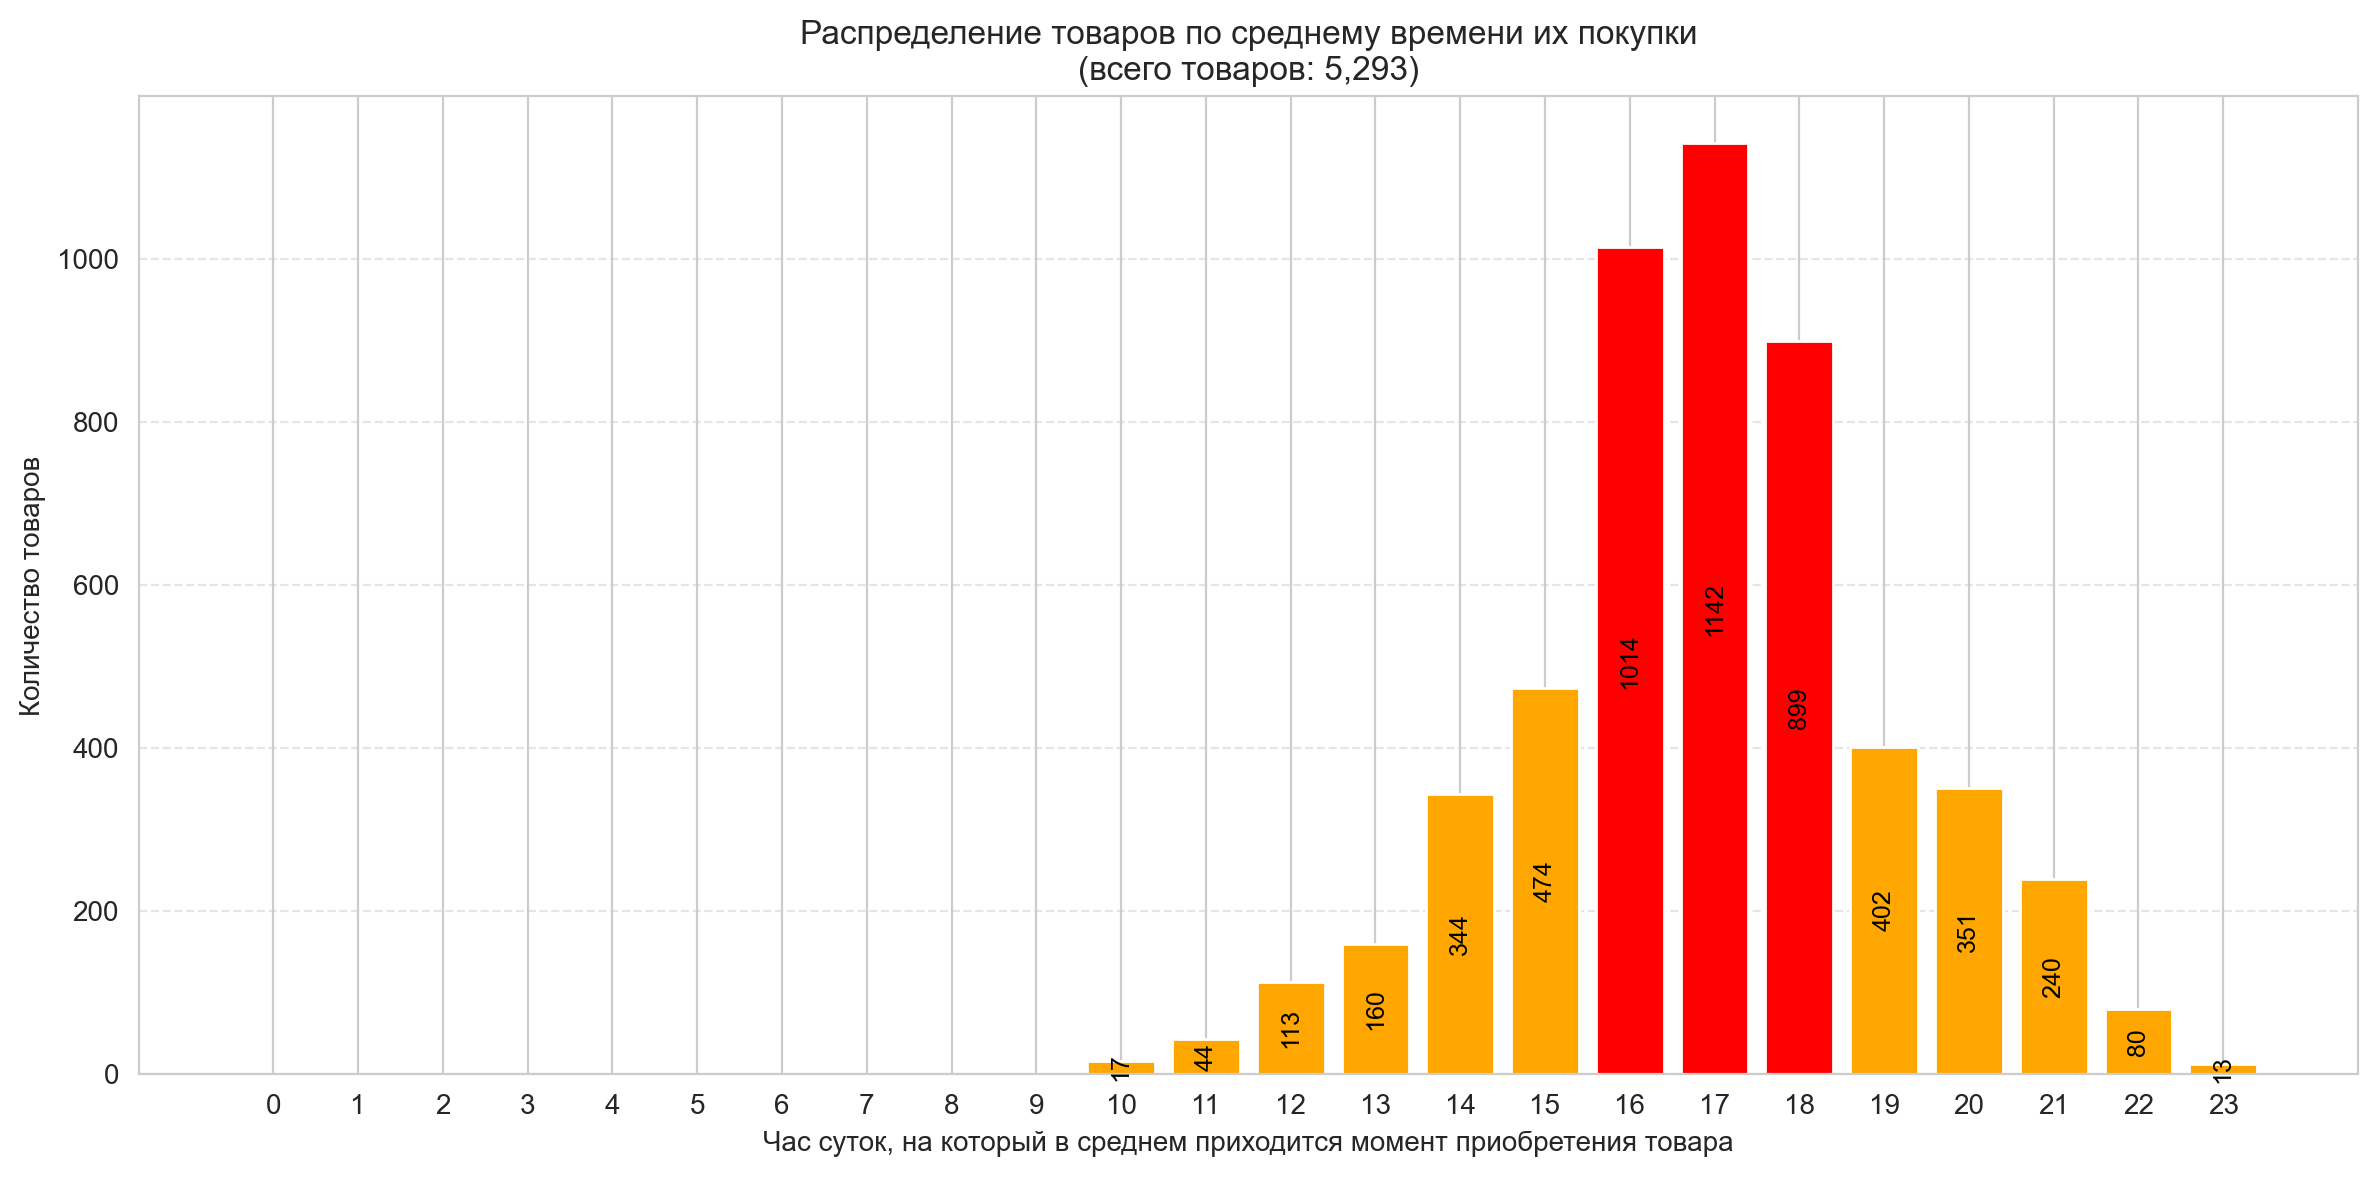

In [32]:
# для отображения всех часов в сутках: от 0 до 23
all_hours = pd.Series(range(24))
hourly_dist = hourly_dist.reindex(all_hours, fill_value=0)

# визуализация: столбчатая диаграмма
plt.figure(figsize=(12, 6))

colors = ['#FFA700'] * len(hourly_dist)  # базовый цвет для всех часов в сутках
highlight_hours = [16, 17, 18] # выделям три пиковых часа по нагрузке

for i, hour in enumerate(hourly_dist.index): # меняем цвет на красный для пиковых часов
    if hour in highlight_hours:
        colors[i] = 'red'

bars = plt.bar(hourly_dist.index, hourly_dist.values, color=colors, edgecolor='white', width=0.8) # строим график с заданными цветами

# аннотации на столбцах
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f'{int(height)}', 
                 ha='center', va='center', color='black', fontsize=9, rotation=90)

plt.xticks(range(0, 24))
plt.xlabel('Час суток, на который в среднем приходится момент приобретения товара')
plt.ylabel('Количество товаров')
plt.title('Распределение товаров по среднему времени их покупки\n(всего товаров: {:,})'.format(len(avg_time_by_item)))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [33]:
# частота покупок по часам для топ-10 товаров
# получаем список ID топ-10 товаров
top10_items = itempopsum['Товар'].tolist()

# присоединяем обратно к itempopsum
itempopsum = itempopsum.merge(avg_time_by_item, on='Товар', how='left')
itempopsum['Среднее время покупки'] = itempopsum['Среднее время покупки'].round().astype(int)

In [34]:
# считаем количество пот-10 товаров на каждый час
hourly_dist_top10 = itempopsum['Среднее время покупки'].value_counts().sort_index()

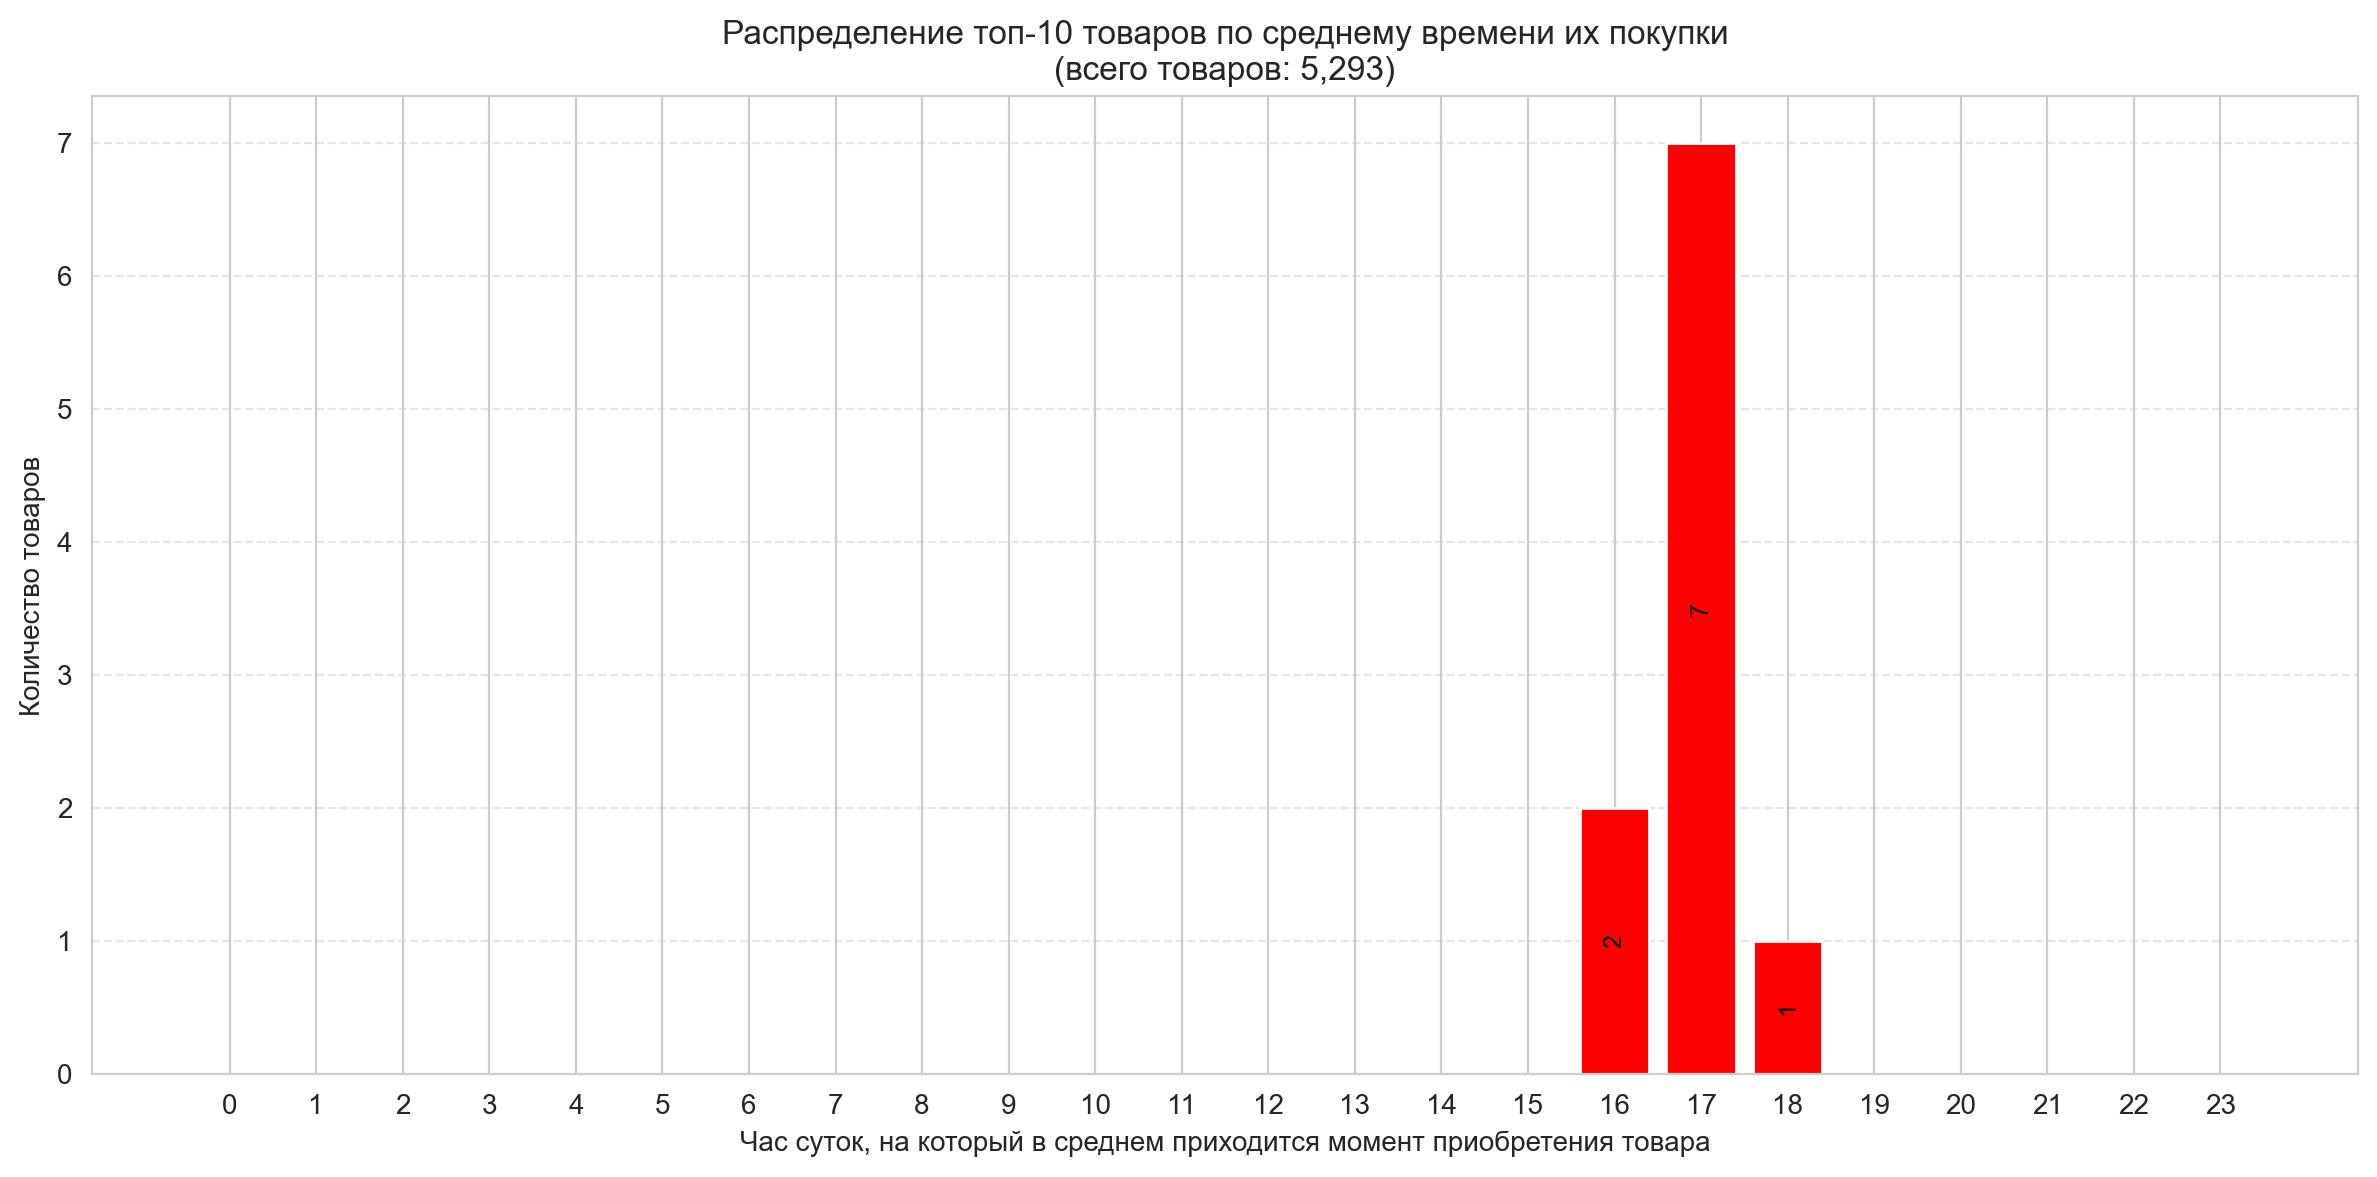

In [35]:
# для отображения всех часов в сутках: от 0 до 23
all_hours = pd.Series(range(24))
hourly_dist_top10 = hourly_dist_top10.reindex(all_hours, fill_value=0)

# визуализация: столбчатая диаграмма
plt.figure(figsize=(12, 6))

colors = ['#FFA700'] * len(hourly_dist_top10)  # базовый цвет для всех часов в сутках
highlight_hours = [16, 17, 18] # выделям три пиковых часа по нагрузке

for i, hour in enumerate(hourly_dist_top10.index): # меняем цвет на красный для пиковых часов
    if hour in highlight_hours:
        colors[i] = 'red'

bars = plt.bar(hourly_dist_top10.index, hourly_dist_top10.values, color=colors, edgecolor='white', width=0.8) # строим график с заданными цветами

# аннотации на столбцах
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f'{int(height)}', 
                 ha='center', va='center', color='black', fontsize=9, rotation=90)

plt.xticks(range(0, 24))
plt.xlabel('Час суток, на который в среднем приходится момент приобретения товара')
plt.ylabel('Количество товаров')
plt.title('Распределение топ-10 товаров по среднему времени их покупки\n(всего товаров: {:,})'.format(len(avg_time_by_item)))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Выводы:** на основе представленных данных о распределении количества уникальных товаров (по ID), проданных в каждый час суток, можно утверждать, что **пик покупательской активности приходится на вторую половину дня**. Наибольшее количество товаров продаётся в 17:00 (1142 товара), что является абсолютным максимумом. Высокая активность наблюдается также в 16:00 (1014) и 18:00 (899). Это указывает на то, что основной поток покупателей — в вечернее время после работы/учёбы, возможно, в промежутке с 16:00 до 19:00. **Минимальная активность** характерная для раннего утра и ночи. С 0:00 до 9:00 практически нет продаж (все значения — 0). Это говорит о том, что магазин (или канал продаж) не используется в ночное и раннее утреннее время, либо покупатели в это время неактивны. **Постепенный рост активности** с 10:00 до 17:00. Активность начинает расти с 10:00 (17 товаров) и ускоряется после обеда: 12:00 — 113, 14:00 — 344, 15:00 — 474. Это вполне может отражать дневной ритм жизни: люди делают покупки в обеденный перерыв или после него, но пик достигается уже ближе к вечеру. **Резкий спад** после 19:00. После 19:00 наблюдается стремительное снижение активности: 19:00 — 402, 22:00 — 80, 23:00 — 13. К 23:00 активность почти прекращается, что логично с точки зрения бытового распорядка.
<br>**Стратегические рекомендации** для маркетинга и акций - наиболее эффективно запускать push-уведомления, email-рассылки или flash-скидки в 15:00–16:00, чтобы «поймать» покупателя перед пиком; для персонала и логистики: обеспечить максимальную готовность склада, касс и онлайн-поддержки с 15:00 до 19:00; по ассортименту: в это время можно продвигать высокомаржинальные или сезонные товары, так как спрос уже высок.

Полученное распределение чётко отражает социально-бытовой цикл потребителей: активность начинается в дневные часы, достигает пика в ранний вечер (16–18 ч) и быстро угасает после 19 часов. Это типичная картина для B2C-ритейла в офлайн- или гибридном формате.

<a id=3.4.3.></a>
#### Шаг 3.4.3. Выявление ключевых прибыльных товаров

Имеющийся в нашем распоряжении список ID товаров может быть отличным инструментом стратегического управления продажами. Так, мы можем выявить ключевые прибыльные товары, рассчитав долю каждого товара в выручке. Это поможет нам понять, какие товары генерируют основую часть дохода и сколько товаров входят в «золотой фонд» и при своём минимальном численном количестве дают максимум выручки. Это основа для приоритизации в управлении ассортиментом, закупках, маркетинге.

In [36]:
# агрегация: таблица эффективности по ассортименту
dfsum = df.groupby(['Товар'])[['Количество', 'Сумма']].sum().reset_index()

Для каждого товара создадим две ключевые метрики:
1. % от общей выручки — показывает, насколько товар важен с точки зрения денег,
2.  % от общего количества продаж — показывает, насколько товар важен с точки зрения объёма/популярности.

In [37]:
# расчёт процентных долей в общей структуре продаж
dfsum['Доля от суммы продаж'] = dfsum['Сумма'] / dfsum['Сумма'].sum() * 100
dfsum['Доля от количества товаров'] = dfsum['Количество'] / dfsum['Количество'].sum() * 100

Отсортируем товары от самого прибыльного к наименее прибыльному. Столбец `Сумма доли продаж` показывает накопленную долю выручки нарастающим итогом. Это позволит быстро выявить:
сколько самых прибыльных товаров дают 80% выручки (принцип Парето), где проходит граница между ключевыми и второстепенными позициями, насколько сконцентрирована выручка (например: «топ-100 товаров — 90% дохода»).

In [38]:
# сортируем полученные значения по выручке + кумулятивная сумма по выручке
dfsum = dfsum.sort_values('Доля от суммы продаж', ascending=False)
dfsum['Сумма доли продаж'] = dfsum['Доля от суммы продаж'].cumsum() # кумулятивная сумма

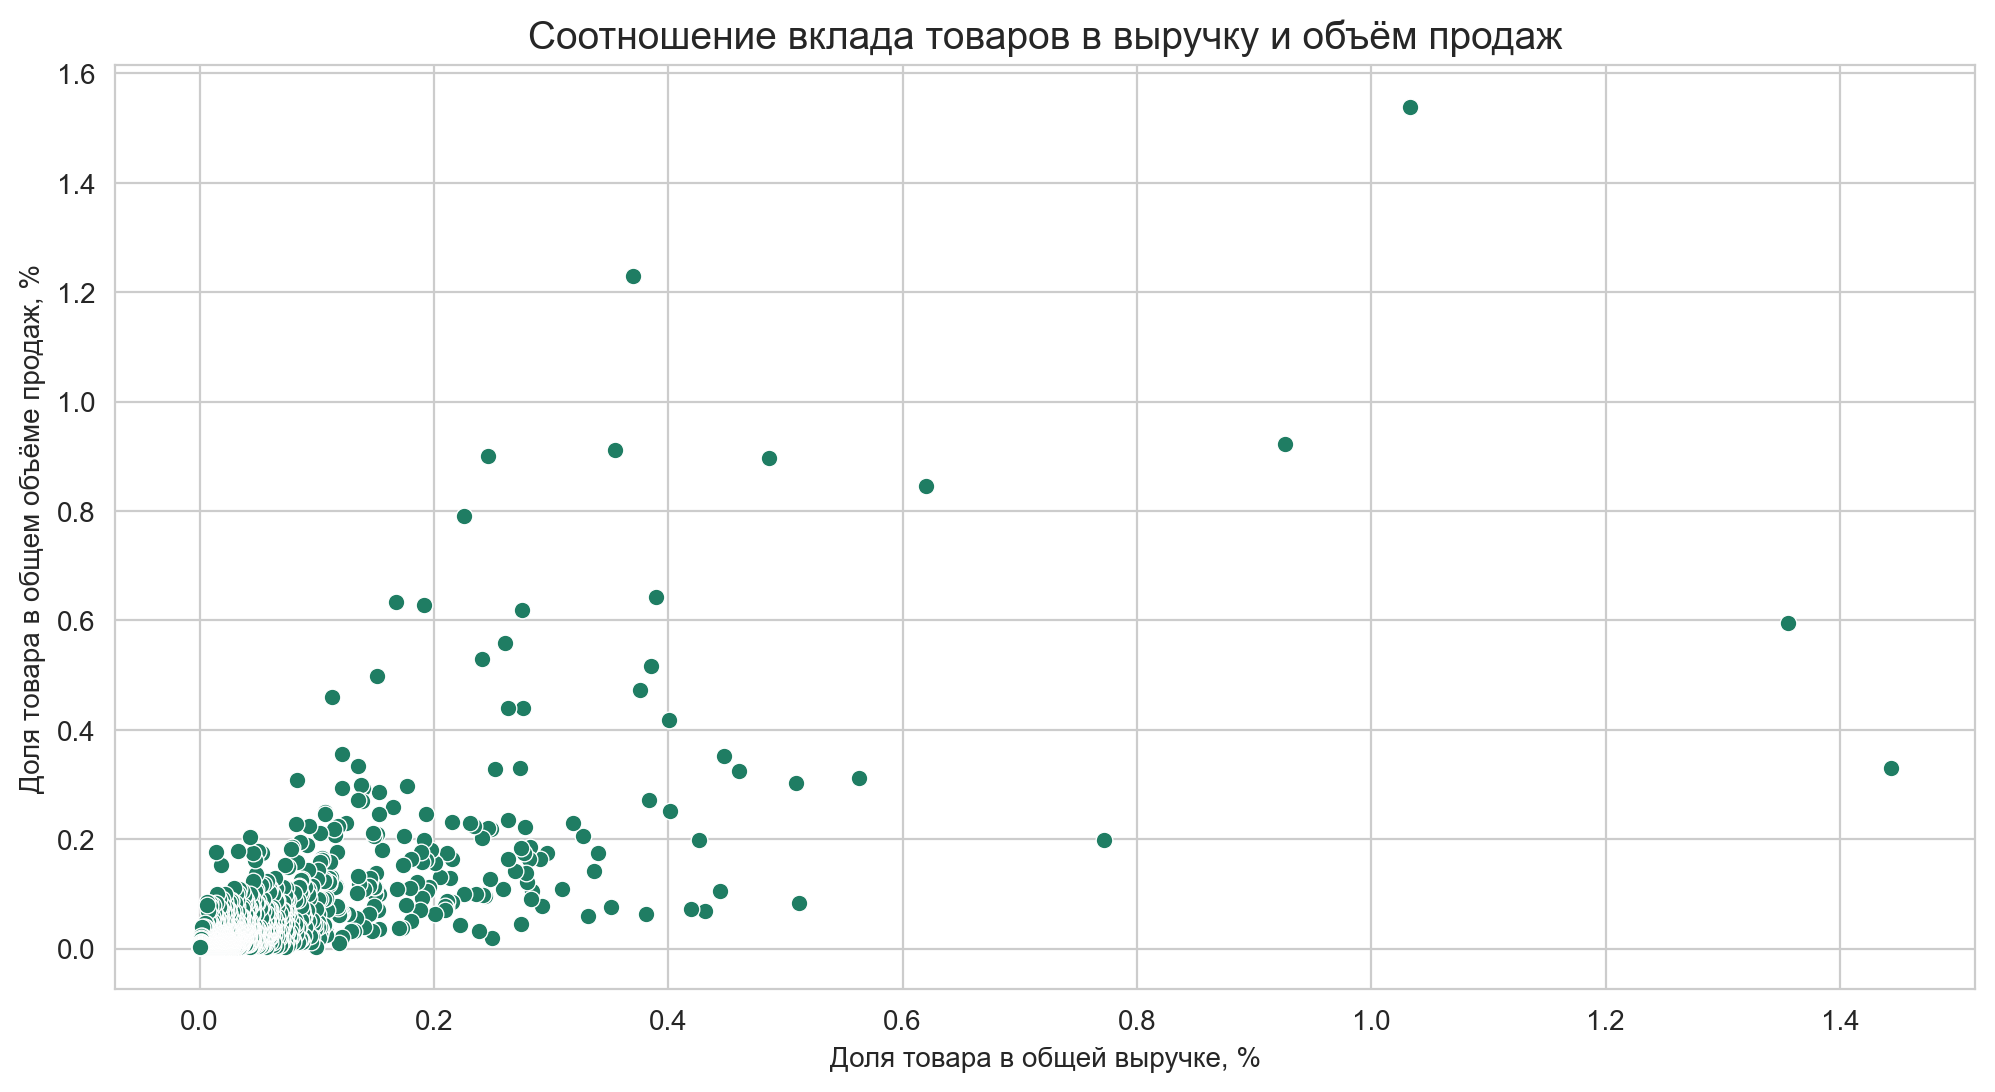

In [39]:
# поиск взаимосвязей: диаграмма рассеяния значений по двум переменным
plt.figure(figsize=(12,6))
sns.scatterplot(data=dfsum, x='Доля от суммы продаж', y='Доля от количества товаров', color='#1F7D63')
plt.title('Соотношение вклада товаров в выручку и объём продаж', fontsize=14)
plt.xlabel('Доля товара в общей выручке, %')
plt.ylabel('Доля товара в общем объёме продаж, %')
plt.show()

На данном графике каждая точка - это один товар. По оси `x` отображается сколько % общей выручки даёт этот товар, по оси `y` - сколько % общего количества составляет этот товар. Товары в верхнем правом углу — и популярные, и прибыльные, в нижнем правом — прибыльные, но редкие (премиум), в верхнем левом — массовые, но дешёвые, в центре — устойчивые середнячки.

Рассчитаем кумулятивную сумму (сумма % продаж), чтобы обратиться к принципу Парето и найти порог, при котором, к примеру, 80% выручки обеспечивается 20% товаров. Это поможет нам ответить на стратегические вопросы: какие товары критически важны для бизнеса и какие можно рассмотреть к исключению из ассортимента?

In [40]:
# применение принципа Парето: сколько товаров дают 80% общей выручки?
# сортировка данных по убыванию доли выручки
dfsum_sorted = dfsum.sort_values('Доля от суммы продаж', ascending=False).reset_index(drop=True)

In [41]:
# расчёт кумулятивной суммы
cumsum_sales = dfsum_sorted['Доля от суммы продаж'].cumsum()

In [42]:
# принцип Парето
top_for_80 = (cumsum_sales >= 80).idxmax() + 1  # +1 так как индексация с 0
print(f"Топ-{top_for_80} товаров обеспечивают ≥80% общей выручки из {len(dfsum)} позиций.")

Топ-1093 товаров обеспечивают ≥80% общей выручки из 5293 позиций.


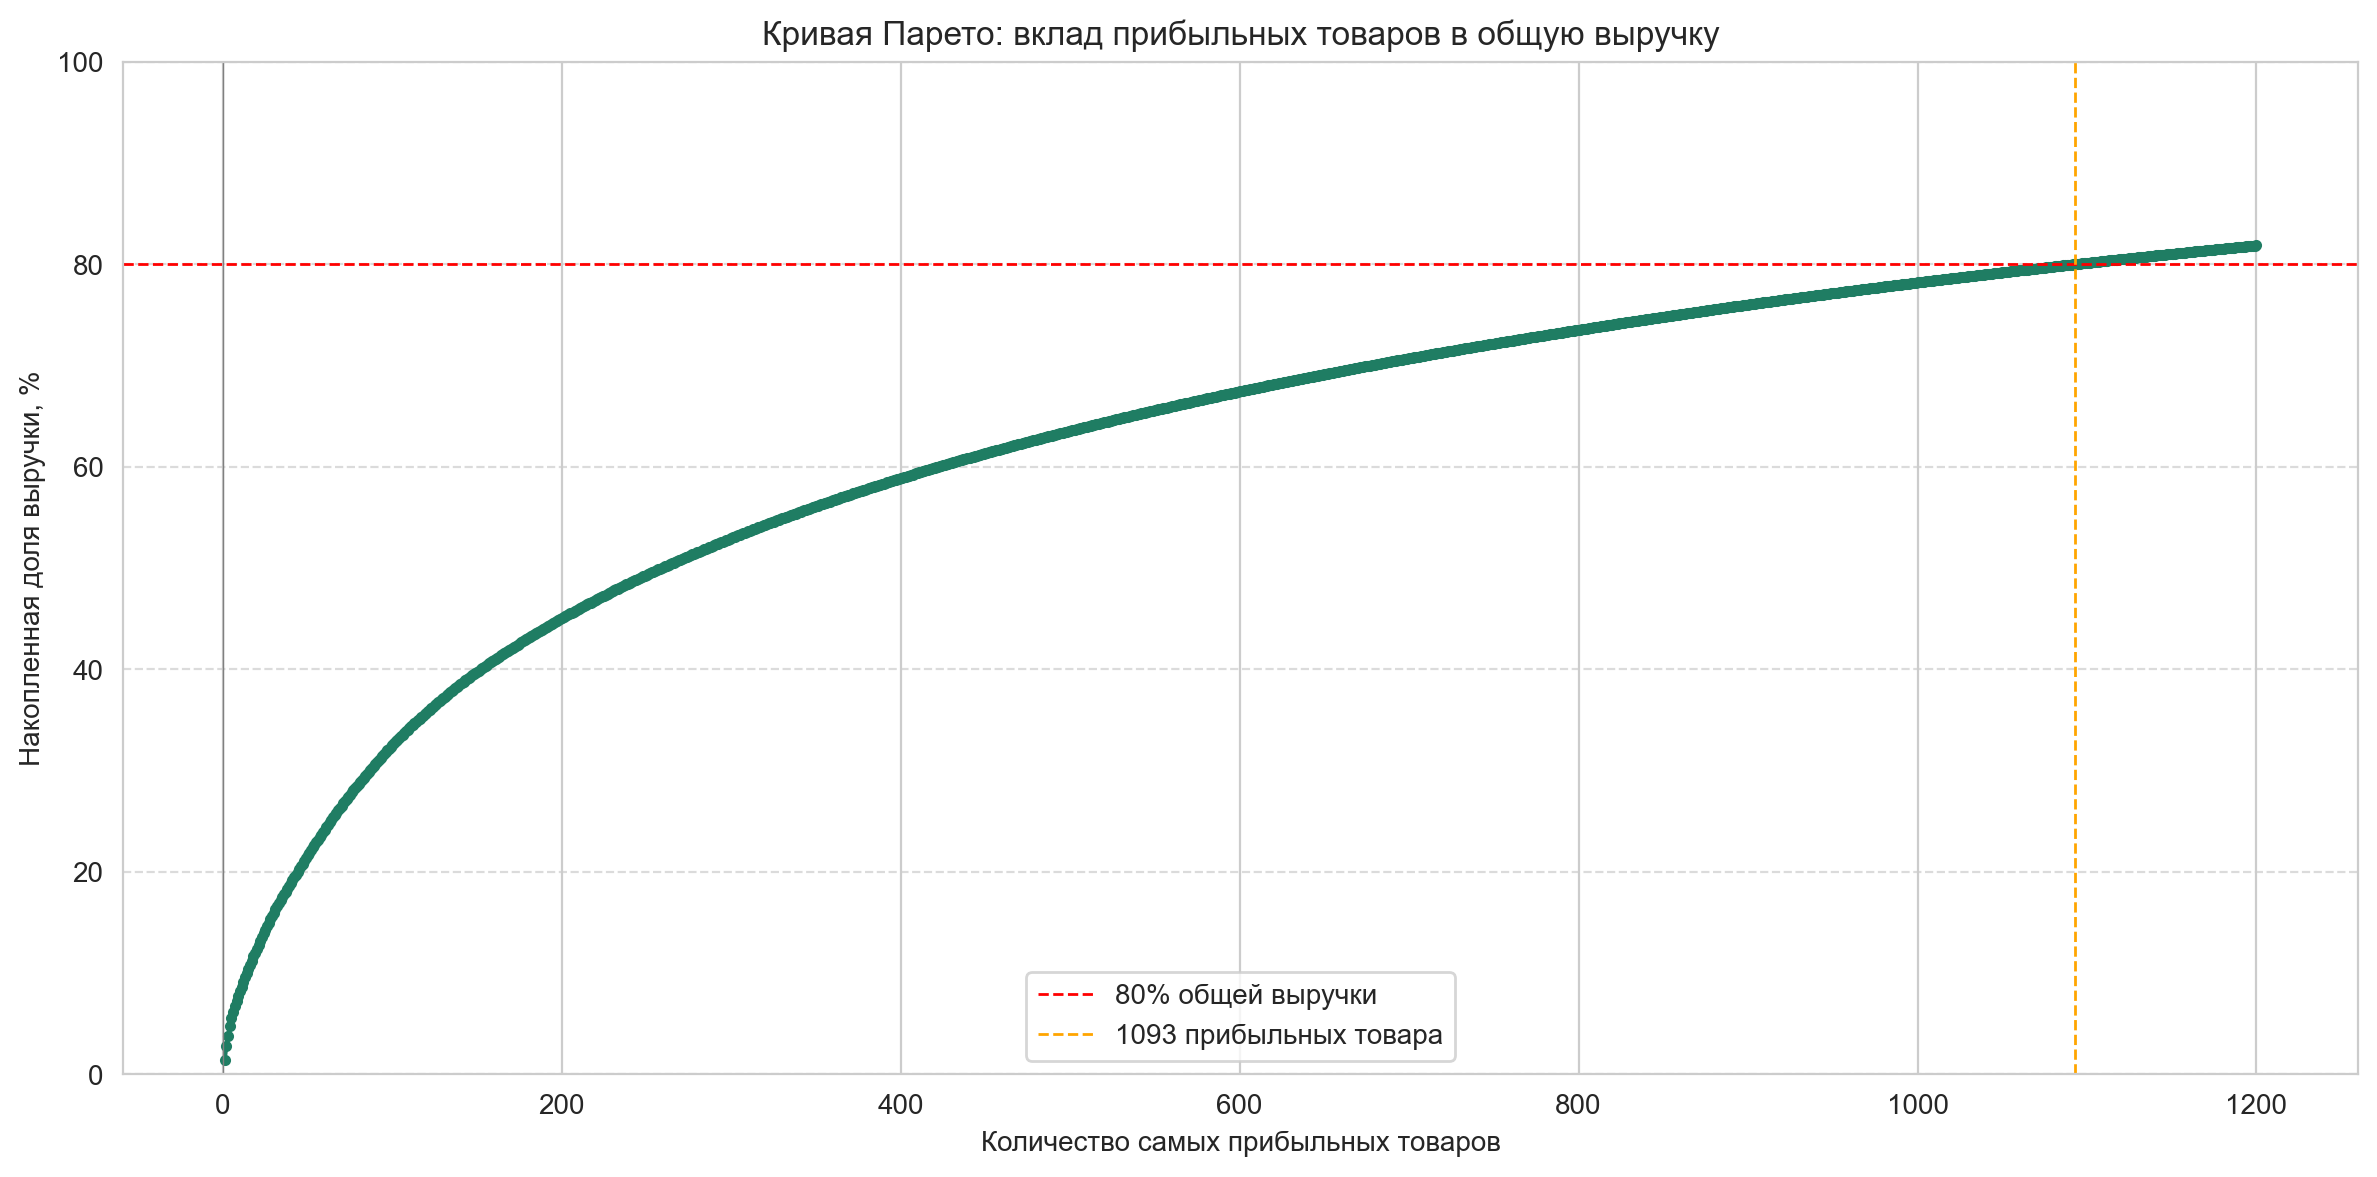

In [43]:
# визуализация кривой Патеро
# ограничиваем число товаров для наглядности
N = min(1200, len(cumsum_sales))  # отображаем 1200 в соответствии с расчётом выше

plt.figure(figsize=(12, 6))
plt.plot(range(1, N + 1), cumsum_sales.iloc[:N], marker='o', markersize=3, linewidth=1.5, color='#1F7D63')

# добавляем на график линию 80% (правило Парето)
plt.axhline(y=80, color='red', linestyle='--', linewidth=1, label='80% общей выручки')
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.axvline(x=1093, color='orange', linestyle='--', linewidth=1, label='1093 прибыльных товара')

plt.xlabel('Количество самых прибыльных товаров')
plt.ylabel('Накопленная доля выручки, %')
plt.title('Кривая Парето: вклад прибыльных товаров в общую выручку')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

По результатам вычислений «Топ-1093 товаров обеспечивают ≥80% общей выручки из 5293 позиций» — мы видим классическое проявление закона Парето (80/20), но в нашем случае соотношение ~20,7% товаров → 80% выручки. Этот инсайт имеет важные практические следствия для анализа и управления продажами. 
<br>**1. Ассортимент не сильно сконцентрирован — средняя диверсификация**
<br>В «идеальном» Парето часто 20% товаров дают 80% выручки. У вас — 20,7%, что близко. Однако это не ультра-сконцентрированный портфель (где, например, 5% товаров = 80% выручки), а умеренно диверсифицированный. Бизнес не зависит от узкой группы «супер-звёзд», но и не распыляется на тысячи малодоходных позиций.
<br>**2. Возможности для оптимизации ассортимента**
<br>4200 товаров (5293 – 1093) генерируют всего ~20% выручки. Это открывает возможность cократить «хвост» ассортимента b исключить низкооборотные/убыточные позиции, jсвободить складские площади и снизить затраты на логистику, учёт, закупки, а также упростить управление и сфокусироваться на 1093 ключевых SKU.
<br>**3. Риски и устойчивость бизнеса**
<br>Зависимость от 1093 позиций — умеренный риск. Если спрос на них упадёт (конкуренция, сезонность, устаревание), то выручка сильно пострадает. Следует анализировать стабильность спроса на топ-товары и развивать новые потенциальные «звёзды» из группы B.
<br>**4. Маркетинг и персонализация**
<br>Топ-1093 товаров — ядро предложения. Их можно продвигать в рекомендательных системах, использовать в кросс-сейле/апсейле, а также отдельно анализировать совместные покупки.

<a id=3.5.></a>
### Шаг 3.5. Корреляция

In [44]:
# поиск взаимосвязей: корреляция
corr = df[['Транзакция', 'Клиент', 'Товар', 'Сумма', 'Время покупки']].corr().round(3)

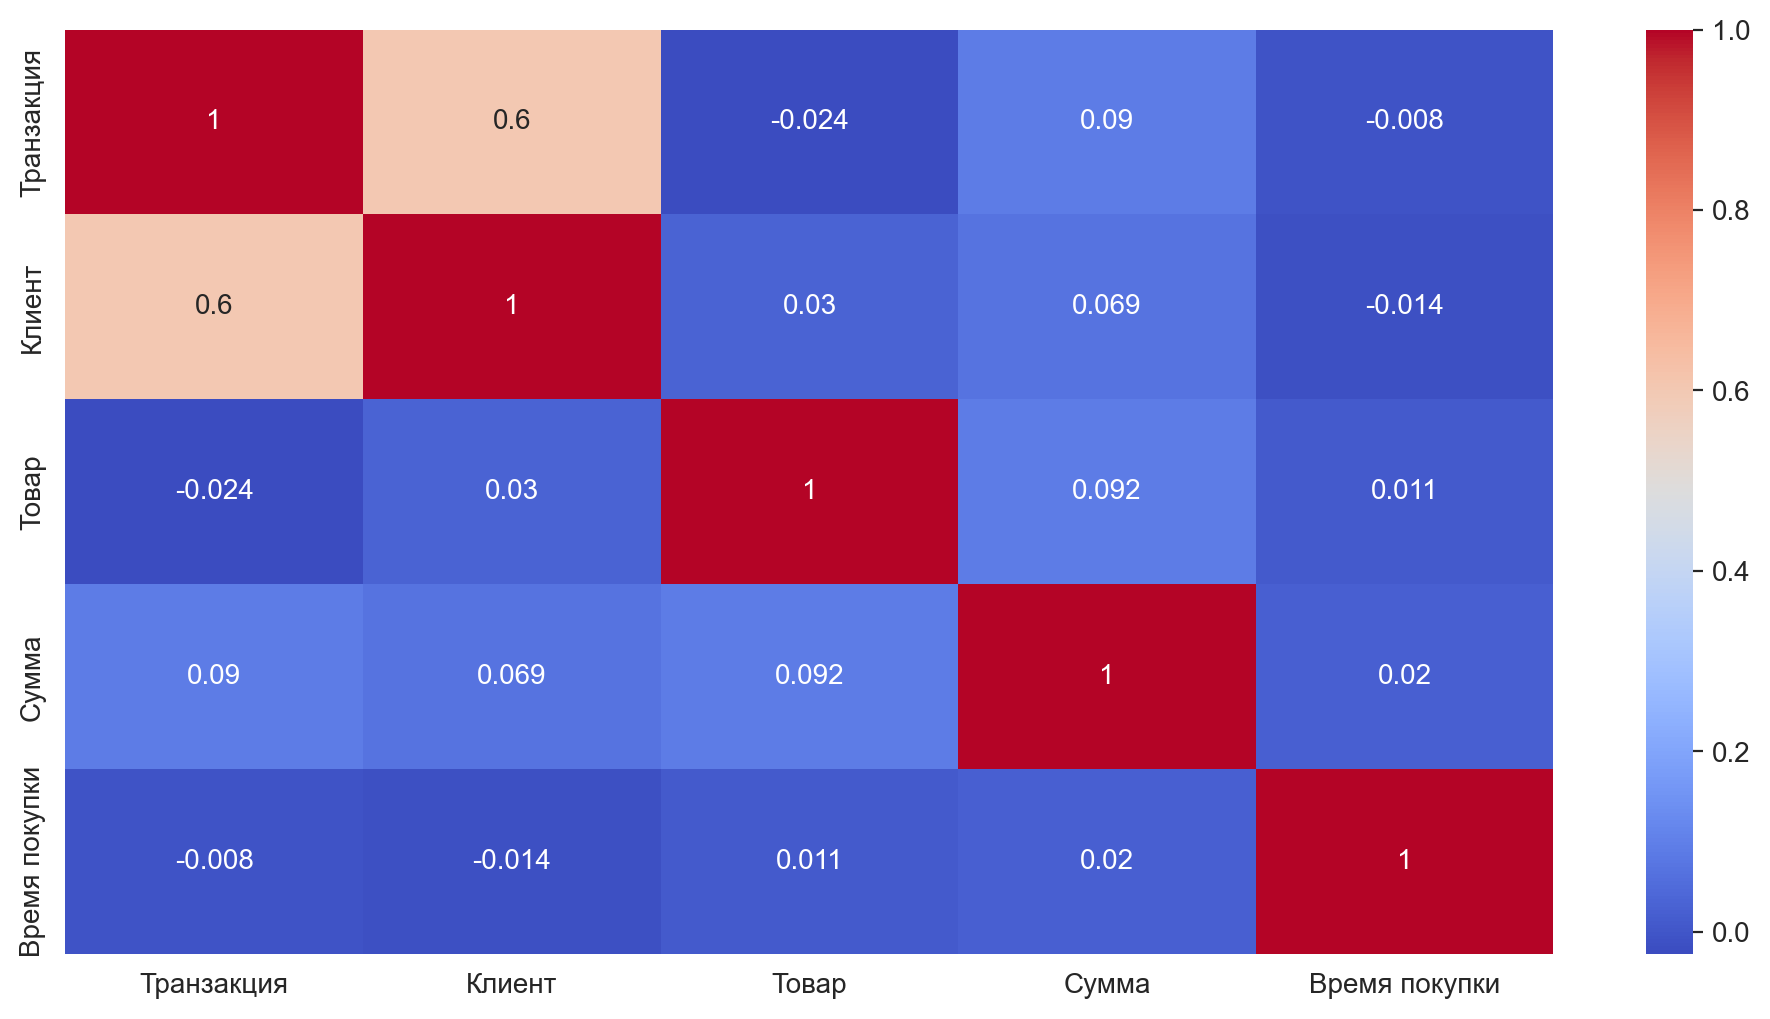

In [45]:
# поиск взаимосвязей: тепловая карта отображения индивидуальных значений данных при помощи цвета
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

In [46]:
# поиск взаимосвязей: расчёт коэффициента линейной связи переменных
a = df['Клиент']
b = df['Транзакция']
rho_coef, rho_p = spearmanr(a, b)
r_coef, r_p = pearsonr(a, b)
print('Коэффициент Пирсона %0.3f | Коэффициент Спирмана %0.3f' 
      % (r_coef, rho_coef))

Коэффициент Пирсона 0.603 | Коэффициент Спирмана 0.581


**Вывод:** Для установления корреляционной зависимости между переменными мы использовали метод `corr`. Корреляция показывает меру взаимосвязи (наличие или отсутствие) между двумя величинами. Чем значение корреляции ближе от 0 к 1, тем синхроннее движутся анализируемые показатели. Если значение корреляции находится в промежутке от `0` до `-1`, то между переменными существует обратная взаимосвязь: рост одной величины приводит к падению другой.
<br>Условиям нашей исследовательской задачи соответствуют «тёплые» цветовые значения, находящиеся в промежутке от `0` до `1`. Сильная корреляция между «Транзакция» и «Клиент» (`r ≈ 0.603`) - это умеренная положительная связь. Означает, что номер транзакции и идентификатор клиента связаны — например, транзакции нумеруются последовательно, и клиенты совершают покупки хронологически (новые клиенты появляются вместе с ростом числа транзакций).
Здесь следует обратить внимание, что это не причинно-следственная связь, а артефакт структуры данных (например, обе переменные возрастают со временем)
<br>Все остальные корреляции - слабые (`|r| < 0.1`):
<br>Между «Товар» и «Сумма»: r = 0.092 — почти нет линейной связи.
<br>Между «Сумма» и «Время покупки»: r = 0.020 — почти нет зависимости суммы от времени суток.
<br>Между «Товар» и «Время покупки»: r = 0.011 — время покупки не связано с конкретным ID товара в линейном смысле.
<br>Таким образом, ни одна из количественных характеристик (ID товара, сумма чека, время покупки) не демонстрирует выраженной линейной зависимости друг от друга.

<a id=4></a>
## Шаг 4. Анализ динамики клиентской активности и удержания

<a id=4.1.></a>
### 4.1. Зависит ли частота покупок от месяца?

In [47]:
# формиурем переменную с хронологическими данными по месяцу 
purchase_months = pd.to_datetime(df['Дата покупки']).dt.month

In [48]:
# считаем количество покупок по месяцам
monthly_counts = purchase_months.value_counts().reindex(range(1, 13), fill_value=0).sort_index()

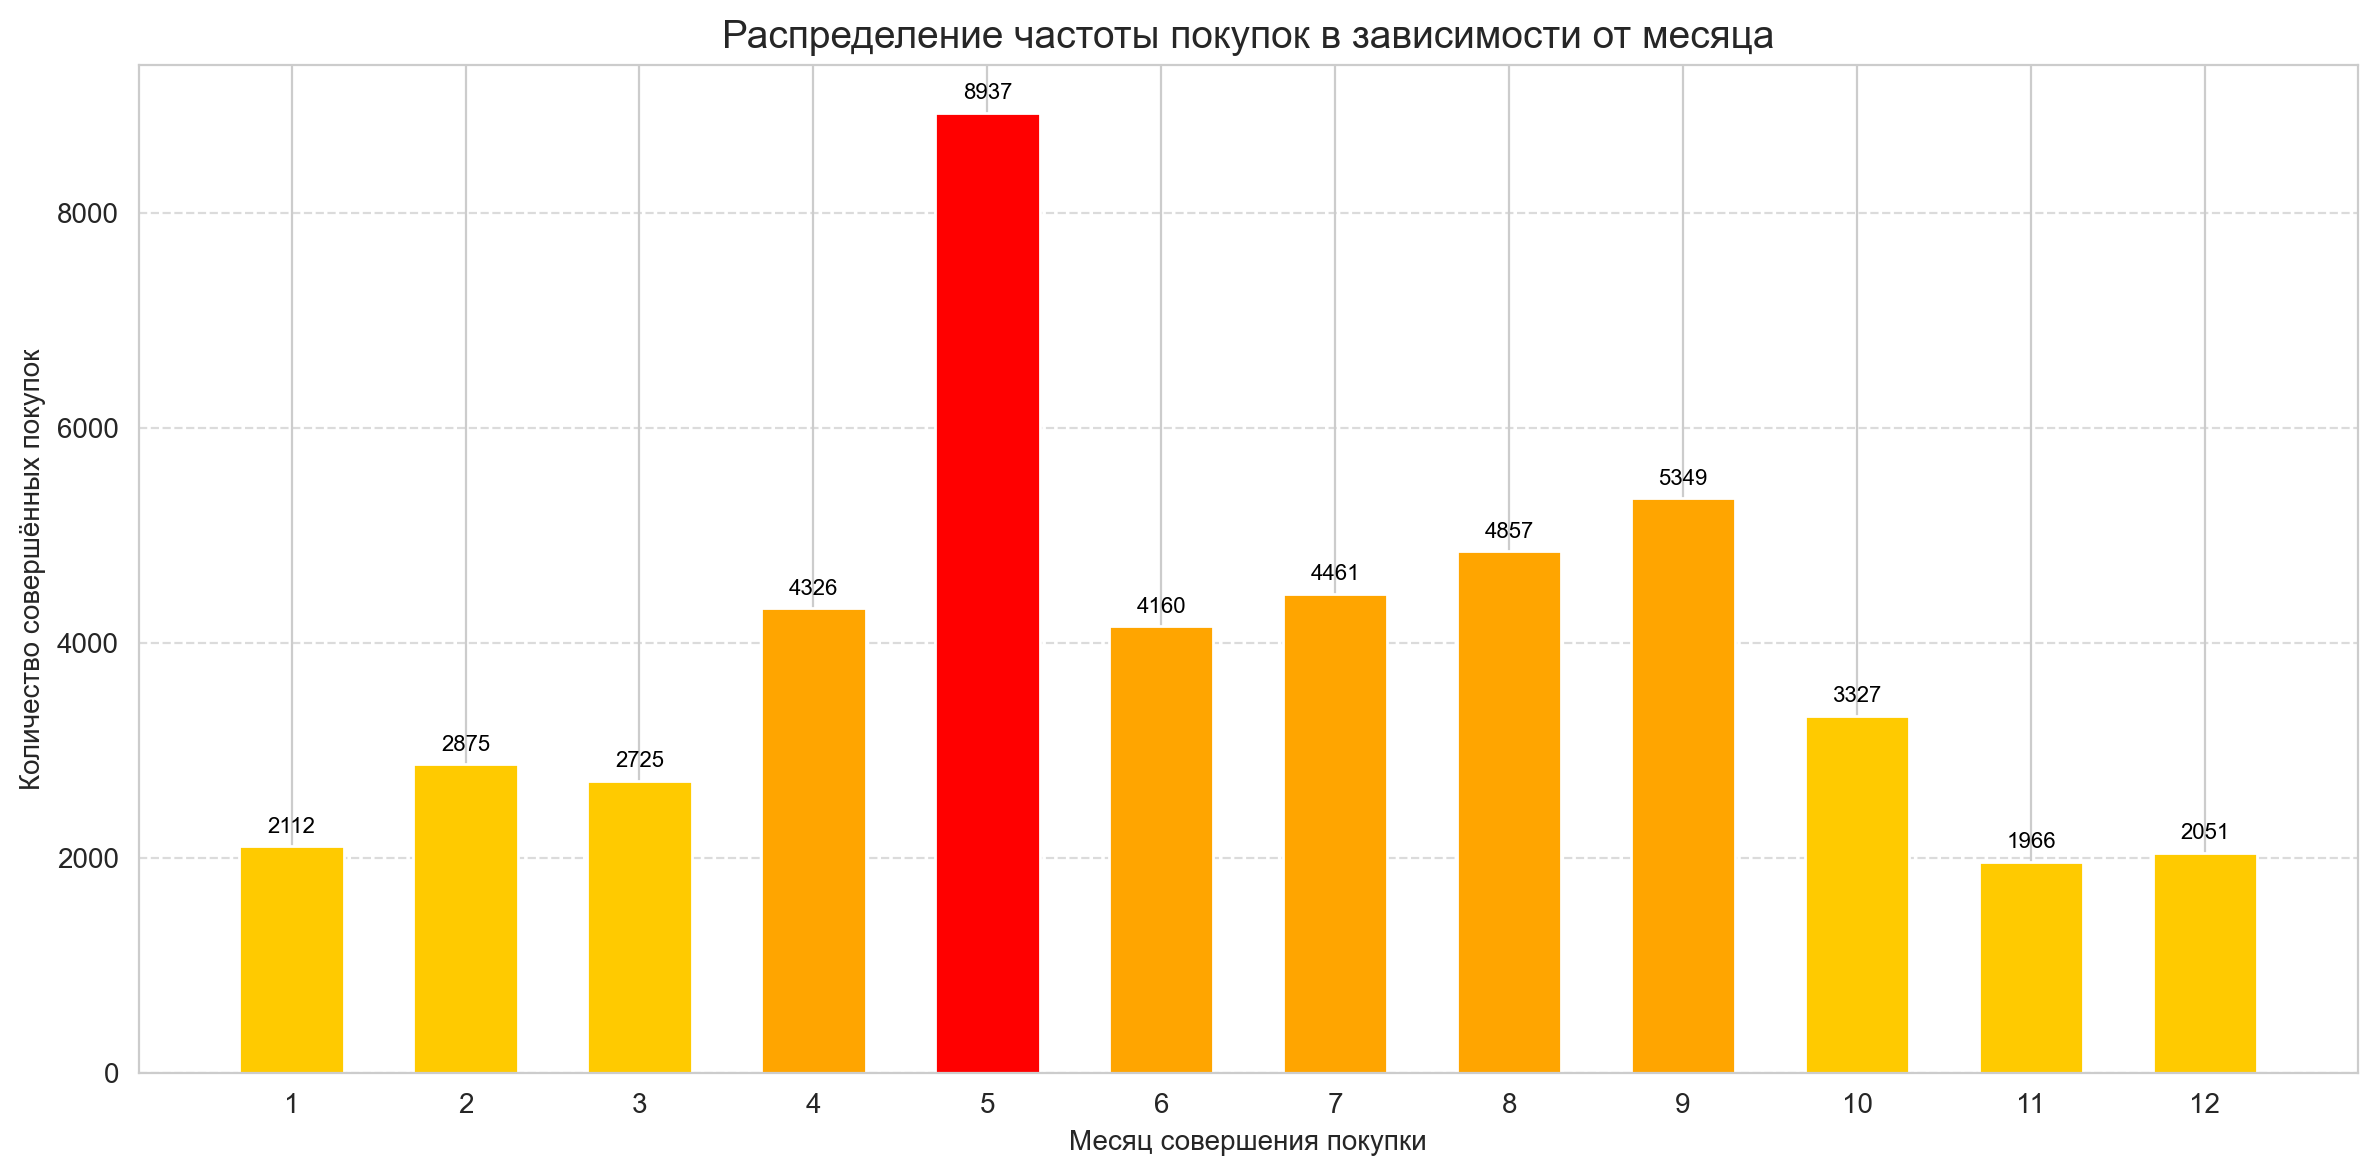

In [49]:
# определяем цвета для каждого месяца
colors = []
for month in range(1, 13):
    if month == 5:
        colors.append('red')          # май — красный
    elif month in [4, 6, 7, 8, 9]:
        colors.append('orange')       # апрель, июнь, июль, август, сентябрь — оранжевые
    else:
        colors.append('#FFCA00')       # остальные — жёлтые

# визуализация: распределение частоты покупок в зависимости от месяца
plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_counts.index, monthly_counts.values, color=colors, edgecolor='white', width=0.6)

# аннотации
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + max(monthly_counts.values) * 0.01, f'{int(height)}', ha='center', va='bottom', fontsize=8, color='black')

plt.title('Распределение частоты покупок в зависимости от месяца', fontsize=14)
plt.xlabel('Месяц совершения покупки')
plt.ylabel('Количество совершённых покупок')
plt.xticks(ticks=range(1, 13), labels=range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Вывод:** Ключевые наблюдения: пик продаж — май отмечен 8937 покупок, что в 2–4 раза выше, чем в большинстве других месяцев. Это абсолютный максимум года. Высокая активность в тёплые месяцы (апрель–сентябрь) от 4160 до 5349 продаж. Среднее за этот период: ~5014 покупок/месяц. Спад в холодное время года (октябрь–март), особенно низкие значения в ноябре - 1966 продаж. Среднее за этот период: ~2330 покупок/месяц — почти в 2 раза ниже, чем весной/летом. Февраль и март — восстановление после новогоднего спада, в среднем 2800 покупок. Рост по сравнению с декабрём/январём, но до «летнего» уровня ещё далеко.
<br>**Возможные гипотезы для бизнеса:** май может быть связан с `сезонным спросом` (например, подготовка к лету, праздники, отпускам), `маркетинговыми акциями` (распродажи, промокоды), `особенностями товарной категории` (например, сезонные товары). Низкие продажи в ноябре–декабре — необычно (обычно ожидается рост к Новому году). Возможно, ассортимент не включает подарочные/праздничные товары, или конкуренция в этот период выше. Необходимо тщательно планировать маркетинг: усилить активность в низкие месяцы (январь, ноябрь) и поддерживать импульс в тёплый сезон (апрель–сентябрь).

<a id=4.2></a>
### 4.2 Больше лучших клиентов, чем потерянных клиентов?

In [50]:
# выберем из датасета необходимые для работы признаки и создадим на их основе новый датасет
temp = ['Клиент', 'Транзакция', 'Дата покупки', 'Сумма']
RFM_data = df[temp]

In [51]:
# получим значения RFM в отношении каждого покупателя
# в датасете последняя транзакция проведена 12 июля 2021 года, возьмём эту дату в качестве текущего момента и переведём её в формат времени
# преобразуем 'Дата покупки' в datetime
RFM_data['Дата покупки'] = pd.to_datetime(RFM_data['Дата покупки'])

# устанавливаем "текущую" дату — это последняя транзакция в данных
now = dt.datetime(2021, 7, 12)

# RFM-таблица
RFM_table = RFM_data.groupby('Клиент').agg({
    'Дата покупки': lambda x: (now - x.max()).days,  # Recency: сколько дней с последней покупки
    'Транзакция': 'count',                           # Frequency: количество транзакций
    'Сумма': 'sum'                                   # Monetary: общая сумма покупок
})

# переименуем столбцы
RFM_table.rename(columns={
    'Дата покупки': 'Recency-Давность',
    'Транзакция': 'Frequency-Частота',
    'Сумма': 'Monetary_value-Деньги'
}, inplace=True)

RFM_table.head()

,Recency-Давность,Frequency-Частота,Monetary_value-Деньги
Клиент,,,
1,216,3,14940
2,57,9,88540
3,435,1,7100
4,-11,64,351196
5,433,1,3035


In [52]:
# для расчёта сегментов RFM используем квантили
# разделим данные на равные части на основе доступных значений
quantiles = RFM_table.quantile(q = [0.25, 0.5, 0.75])
quantiles

,Recency-Давность,Frequency-Частота,Monetary_value-Деньги
0.25,64.0,1.0,7490.0
0.50,165.0,2.0,17545.0
0.75,314.0,4.0,41490.0


In [53]:
# преобразуем формат квантилей в тип словарь
quantiles = quantiles.to_dict()

# сделаем копию начальной таблицы RFM сегментирования
RFM_Segment = RFM_table.copy()

# создадим функцию для рассчёта сегментов давности
# установим аргументы: x = значение, p = давность, частота, деньги, k = словарь соответствующего квартиля
def R_Class(x,p,d):
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]: 
        return 2
    else:
        return 1

# создадим функцию для рассчёта сегментов частоты и денег
# установим аргументы: x = значение, p = давность, частота, деньги, k = словарь соответствующего квартиля
def FM_Class(x,p,d):
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]: 
        return 3
    else:
        return 4

In [54]:
# создаём новую таблицу с дополнительными признаками и заполняем её соответствующими значениями
# выведем первые cтроки полученной таблицы сегментов RFM
RFM_Segment['R_Quartile'] = RFM_Segment['Recency-Давность'].apply(R_Class, args=('Recency-Давность',quantiles,))
RFM_Segment['F_Quartile'] = RFM_Segment['Frequency-Частота'].apply(FM_Class, args=('Frequency-Частота',quantiles,))
RFM_Segment['M_Quartile'] = RFM_Segment['Monetary_value-Деньги'].apply(FM_Class, args=('Monetary_value-Деньги',quantiles,))
RFM_Segment['RFMClass'] = RFM_Segment.R_Quartile.map(str) \
                            + RFM_Segment.F_Quartile.map(str) \
                            + RFM_Segment.M_Quartile.map(str)
RFM_Segment.head()

,Recency-Давность,Frequency-Частота,Monetary_value-Деньги,R_Quartile,F_Quartile,M_Quartile,RFMClass
Клиент,,,,,,,
1,216,3,14940,2,3,2,232
2,57,9,88540,4,4,4,444
3,435,1,7100,1,1,1,111
4,-11,64,351196,4,4,4,444
5,433,1,3035,1,1,1,111


In [55]:
# определим количество лучших покупателей, их RFMClass = 444
n444 = RFM_Segment[RFM_Segment['RFMClass']=='444'].groupby('Клиент').sum().sort_values('Recency-Давность', ascending=False)
n444.shape[0]

989

In [56]:
# определим количество потерянных покупателей, их RFMClass = 111
n111 = RFM_Segment[RFM_Segment['RFMClass']=='111'].groupby('Клиент').sum().sort_values('Recency-Давность', ascending=True)
n111.shape[0]

933

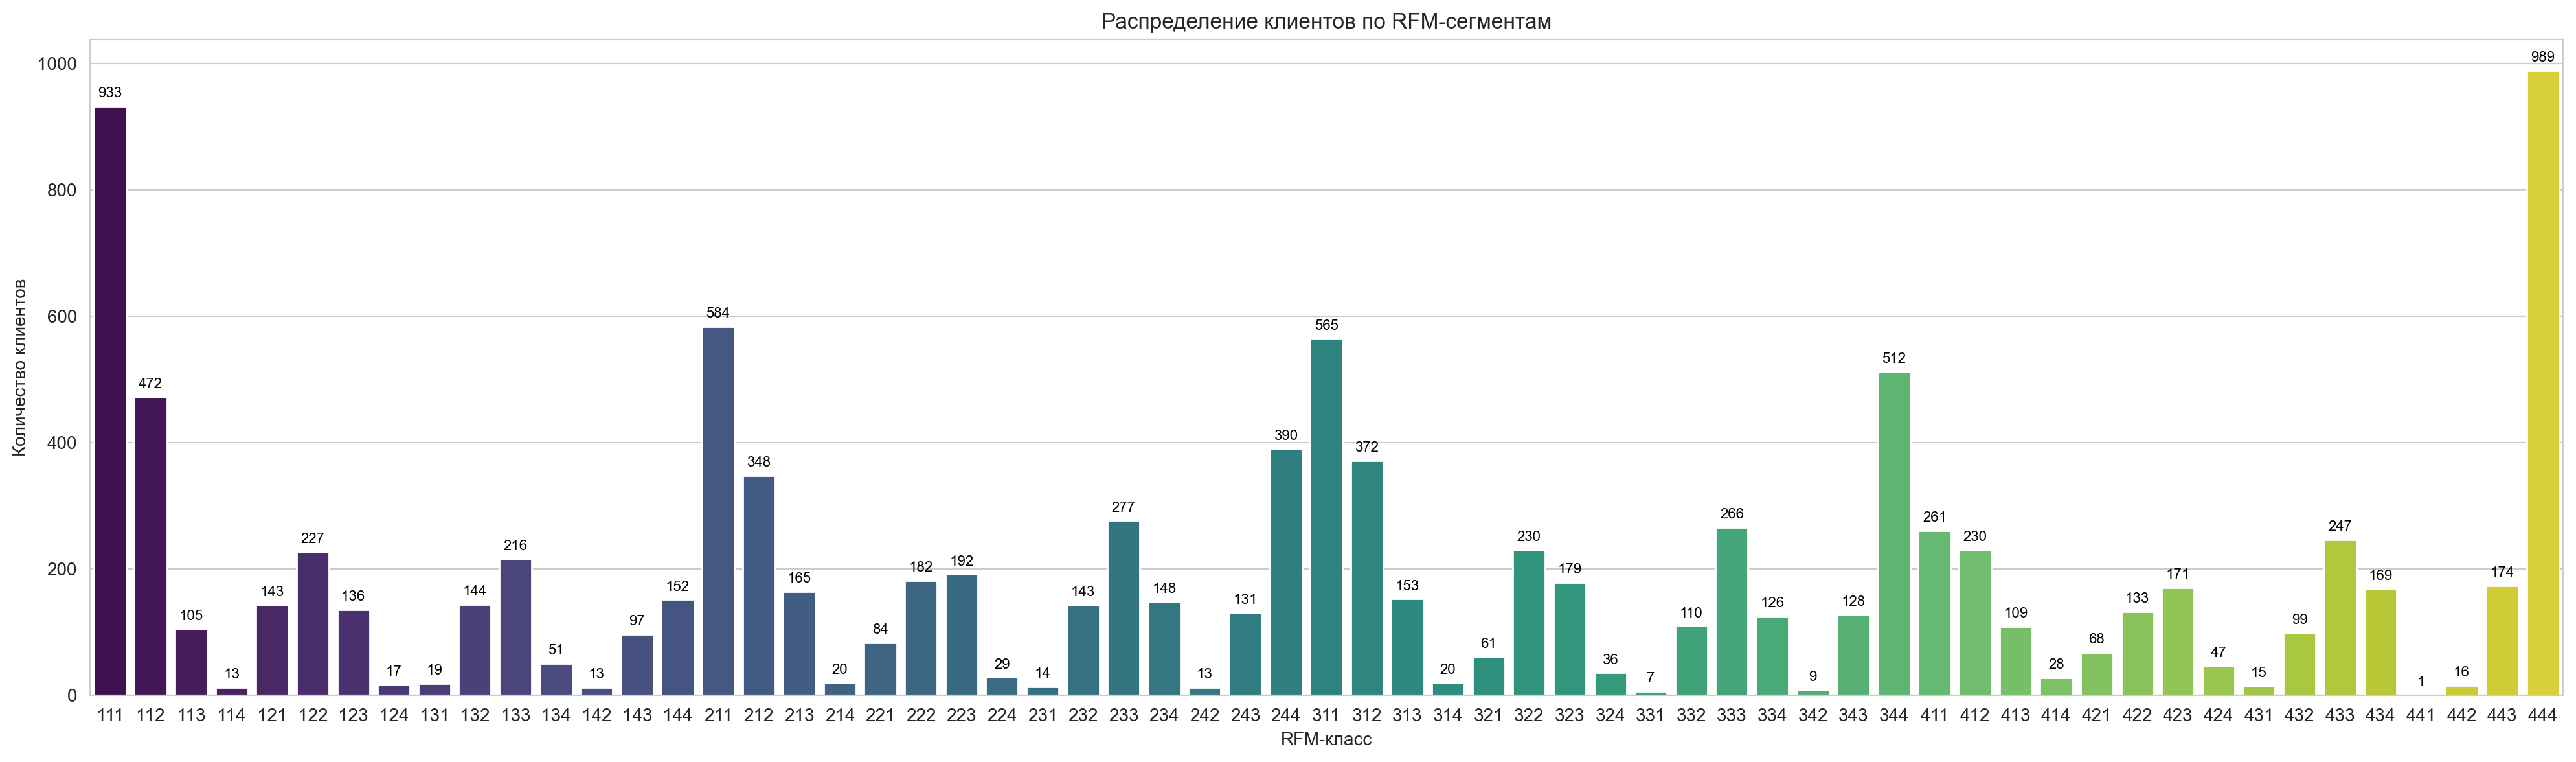

In [57]:
# визуализация количества клиентов в каждом RFM-классе
# для одномерного распределения — barplot
rfm_counts = RFM_Segment['RFMClass'].value_counts().sort_index()

plt.figure(figsize=(20, 6))
ax = sns.barplot(x=rfm_counts.index, y=rfm_counts.values, palette='viridis')

# аннотации
for i, (class_label, count) in enumerate(rfm_counts.items()):
    ax.text(i, count + max(rfm_counts.values) * 0.01, str(count), ha='center', va='bottom', fontsize=8, color='black')

plt.title('Распределение клиентов по RFM-сегментам')
plt.xlabel('RFM-класс')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

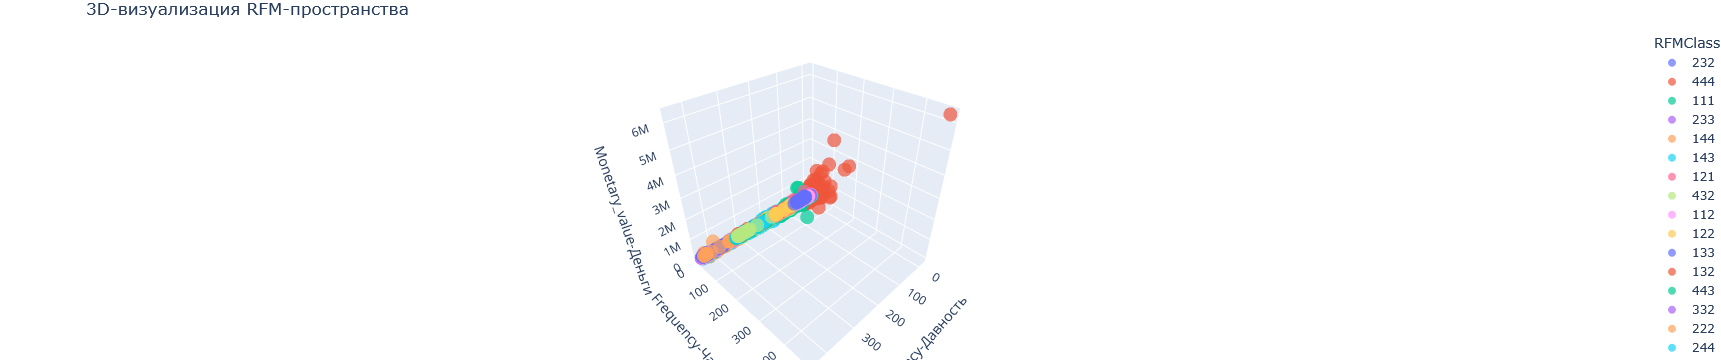

In [58]:
# Ключевая строка — включает offline-рендеринг без расширений
init_notebook_mode(connected=False)

# 3-D визуализация RFM-пространства
fig = px.scatter_3d(
    RFM_Segment.reset_index(),
    x='Recency-Давность',
    y='Frequency-Частота',
    z='Monetary_value-Деньги',
    color='RFMClass',
    hover_name='Клиент',
    title='3D-визуализация RFM-пространства',
    opacity=0.7
)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30))
fig.show()

**Вывод:** сегментирование покупателей в соответствии с их количественной оценкой поведения в отношении объекта торговли является целью RFM-анализа. Покупатели разделяются на группы в соответствии с историей их транзакций: Recency (Давность) — Как давно клиент совершил покупку? Frequency (Частота) — Как часто клиент совершает покупки? Monetary Value (Денежная ценность) — Сколько клиент тратит? Разделим наших покупателей на сегменты, а полученные сегменты упорядочим от наиболее ценных (наибольшая повторяемость, частота и ценность) до наименее ценных (наименьшая повторяемость, частота и ценность). В результате вычислений установлено количественное большинство лучших клиентов, которые покупали недавно, часто и на большую сумму, чем потерянных клиентов: 989 и 933 человек соответственно.

<a id=5></a>
## Шаг 5. Построение рекомендательной системы

<a id=5.1.></a>
### Шаг 5.1. Кластеризация по товарам

In [59]:
# убираем из анализа избыточный признак
dfsum = dfsum.drop('Сумма доли продаж', axis=1)

In [60]:
# кластеризация: рассчитаем сумму квадратов расстояний от объектов кластера до его центроида
Sum_of_squared_distances = []
K = range(1, 20)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(dfsum[['Количество', 'Сумма', 'Доля от суммы продаж', 'Доля от количества товаров']])
    Sum_of_squared_distances.append(km.inertia_)

Sum_of_squared_distances

[401981504685269.0,
 168921038728419.47,
 85431448864581.38,
 47485093770195.29,
 33365968621761.617,
 25908717256259.55,
 15503347538492.371,
 11292681408139.95,
 9253874983459.086,
 7064173830213.77,
 5683315643922.414,
 4963819447325.903,
 4116828752600.0737,
 3625758262084.181,
 2908326052130.5176,
 2660356989773.1465,
 2225922277326.953,
 2053828038863.3657,
 1700499342352.1406]

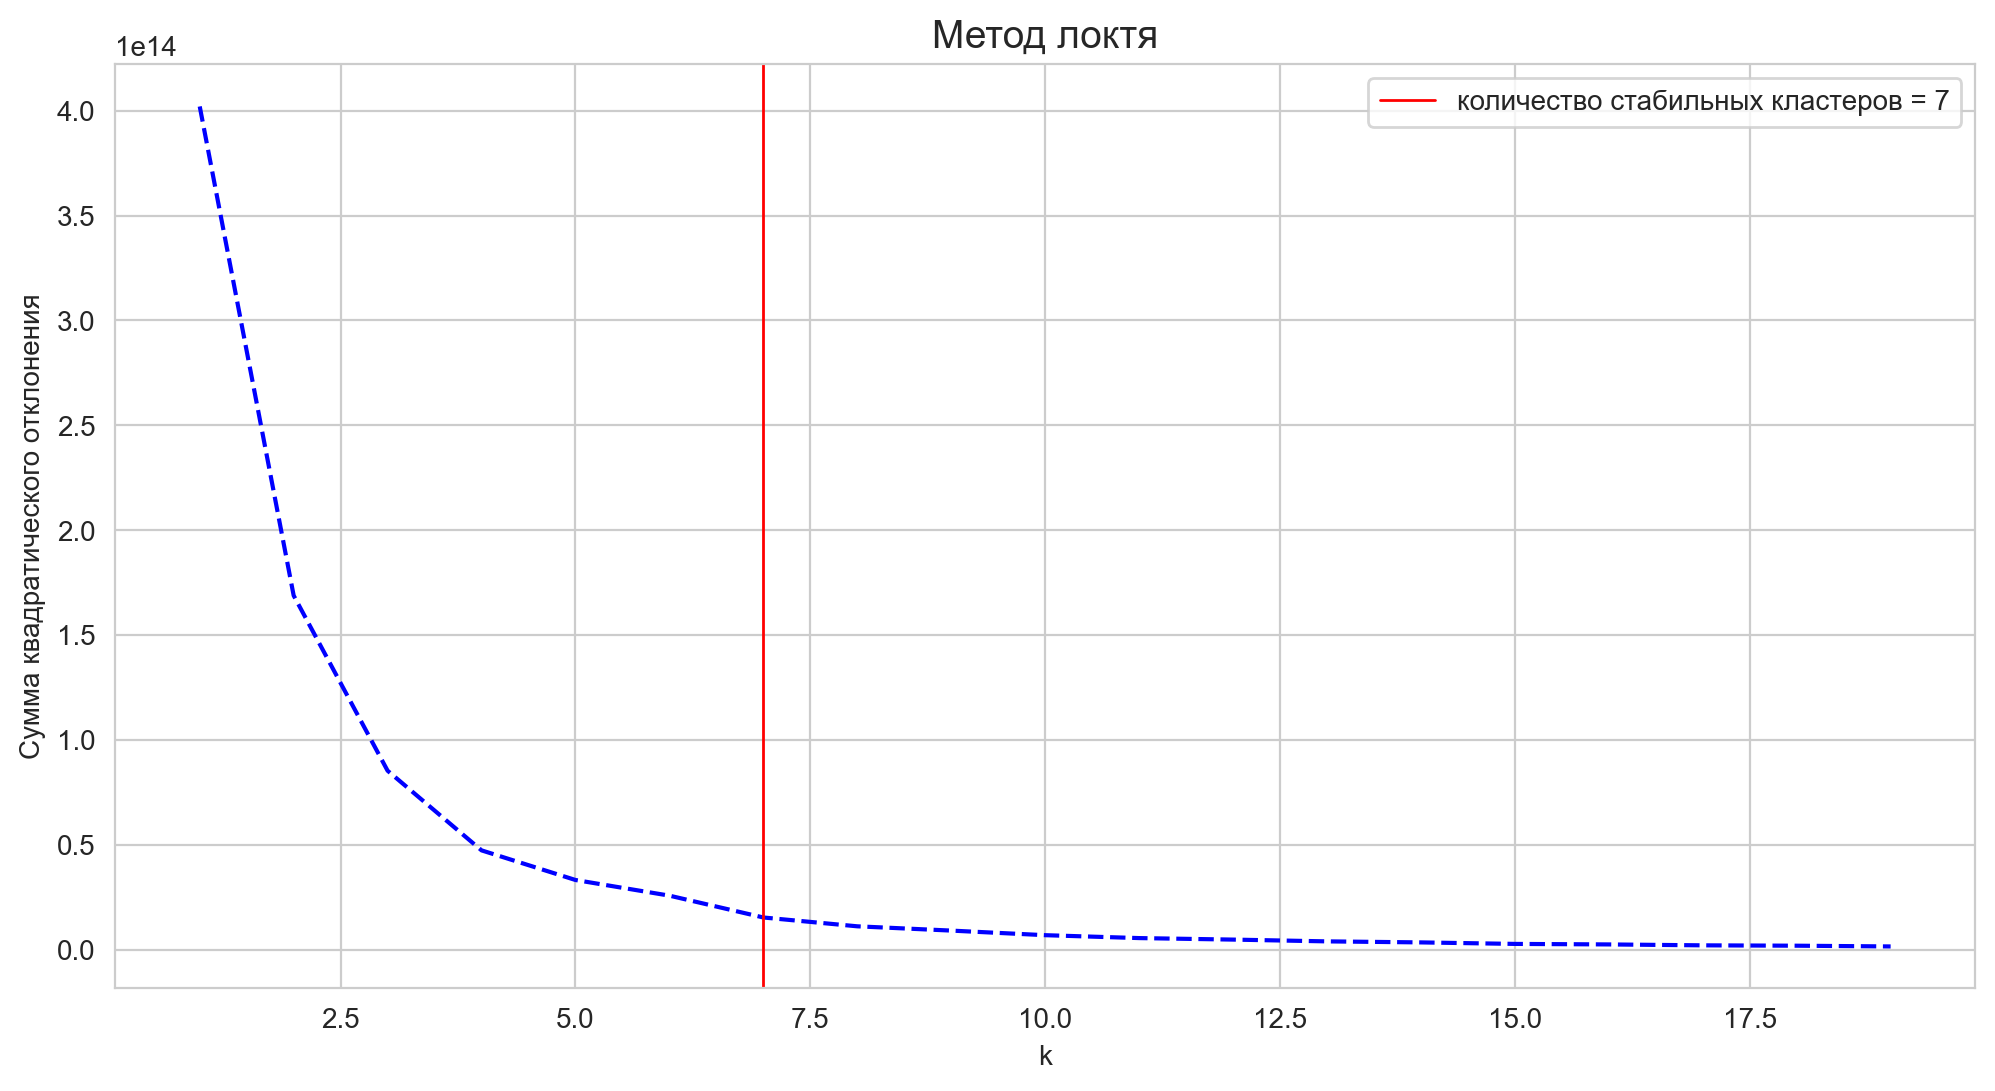

In [61]:
# кластеризация: применение метода локтя
plt.figure(figsize=(12,6))
plt.plot(K, Sum_of_squared_distances, '--', color='blue')
plt.axvline(x=7, color='red', linestyle='-', linewidth=1, label='количество стабильных кластеров = 7')
plt.title('Метод локтя', fontsize=14)
plt.xlabel('k')
plt.ylabel('Сумма квадратического отклонения')
plt.legend() 
plt.show()

In [62]:
# выполним кластеризацию данных с использованием алгоритма K-средних
# Выбираем признаки
features = ['Количество', 'Сумма', 'Доля от суммы продаж', 'Доля от количества товаров']

# масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dfsum[features])

# кластеризация на масштабированных данных
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
dfsum['Кластер'] = kmeans.fit_predict(X_scaled)

dfsum.head()

,Товар,Количество,Сумма,Доля от суммы продаж,Доля от количества товаров,Кластер
2946,3060,156,7114335,1.443299,0.330887,6
4563,4757,281,6684263,1.356049,0.596021,6
4744,4944,725,5092296,1.033084,1.537776,3
3366,3487,435,4566215,0.926357,0.922666,3
2343,2430,94,3805181,0.771964,0.199381,1


In [63]:
# по средним покзателям мы можем установить, какие кластеры — «премиум», «массовые», «низкочастотные»
dfsum.groupby('Кластер').mean()

,Товар,Количество,Сумма,Доля от суммы продаж,Доля от количества товаров
Кластер,,,,,
0,2671.474716,3.182446,3.028738e+04,0.006144,0.006750
1,3389.333333,77.862745,1.605808e+06,0.325773,0.165152
2,3025.066667,268.733333,1.302730e+06,0.264287,0.570002
3,3976.500000,498.666667,3.113352e+06,0.631612,1.057707
4,3667.628099,72.595041,6.589734e+05,0.133687,0.153979
5,3058.781609,20.763547,2.353204e+05,0.047740,0.044041
6,3908.500000,218.500000,6.899299e+06,1.399674,0.463454


In [64]:
# изучим более детально характеристики кластеров товаров
cluster_summary = dfsum.groupby('Кластер').agg({
    'Товар': 'count',          # сколько товаров в кластере
    'Количество': 'sum',       # общий объём продаж по кластеру
    'Сумма': 'sum'             # общая выручка по кластеру
})
cluster_summary['% выручки'] = cluster_summary['Сумма'] / cluster_summary['Сумма'].sum() * 100
cluster_summary

,Товар,Количество,Сумма,% выручки
Кластер,,,,
0,4489,14286,135960042,27.582474
1,51,3971,81896226,16.614444
2,15,4031,19540948,3.964310
3,6,2992,18680112,3.789670
4,121,8784,79735780,16.176150
5,609,12645,143310146,29.073604
6,2,437,13798598,2.799348


In [65]:
# создаём словари сопоставления для описания полученных кластеров
# наименование кластера
cluster_names = {
    5: 'Массовые хиты',
    0: 'Широкий ассортимент',
    1: 'Премиум-звёзды',
    4: 'Стабильные продавцы',
    2: 'Нишевые хиты',
    3: 'Элитные позиции',
    6: 'Эксклюзив'
}

# смысловое описание кластера
cluster_descriptions = {
    5: 'Высокая выручка + высокий объём + много SKU',
    0: 'Огромное число SKU, умеренная маржинальность',
    1: 'Высокая выручка при малом числе SKU',
    4: 'Сбалансированный вклад в объём и выручку',
    2: 'Мало SKU, но каждый — бестселлер в своей нише',
    3: 'Очень дорогие, низкочастотные',
    6: 'Супер-дорогие, почти штучные товары'
}

# добавляем столбцы в таблицу кластеров
cluster_summary['Название кластера'] = cluster_summary.index.map(cluster_names)
cluster_summary['Ключевая характеристика'] = cluster_summary.index.map(cluster_descriptions)

# сортируем по убыванию выручки для лучшей читаемости
cluster_summary = cluster_summary.sort_values('% выручки', ascending=False)

# выводим результат
cluster_summary

,Товар,Количество,Сумма,% выручки,Название кластера,Ключевая характеристика
Кластер,,,,,,
5,609,12645,143310146,29.073604,Массовые хиты,Высокая выручка + высокий объём + много SKU
0,4489,14286,135960042,27.582474,Широкий ассортимент,"Огромное число SKU, умеренная маржинальность"
1,51,3971,81896226,16.614444,Премиум-звёзды,Высокая выручка при малом числе SKU
4,121,8784,79735780,16.176150,Стабильные продавцы,Сбалансированный вклад в объём и выручку
2,15,4031,19540948,3.964310,Нишевые хиты,"Мало SKU, но каждый — бестселлер в своей нише"
3,6,2992,18680112,3.789670,Элитные позиции,"Очень дорогие, низкочастотные"
6,2,437,13798598,2.799348,Эксклюзив,"Супер-дорогие, почти штучные товары"


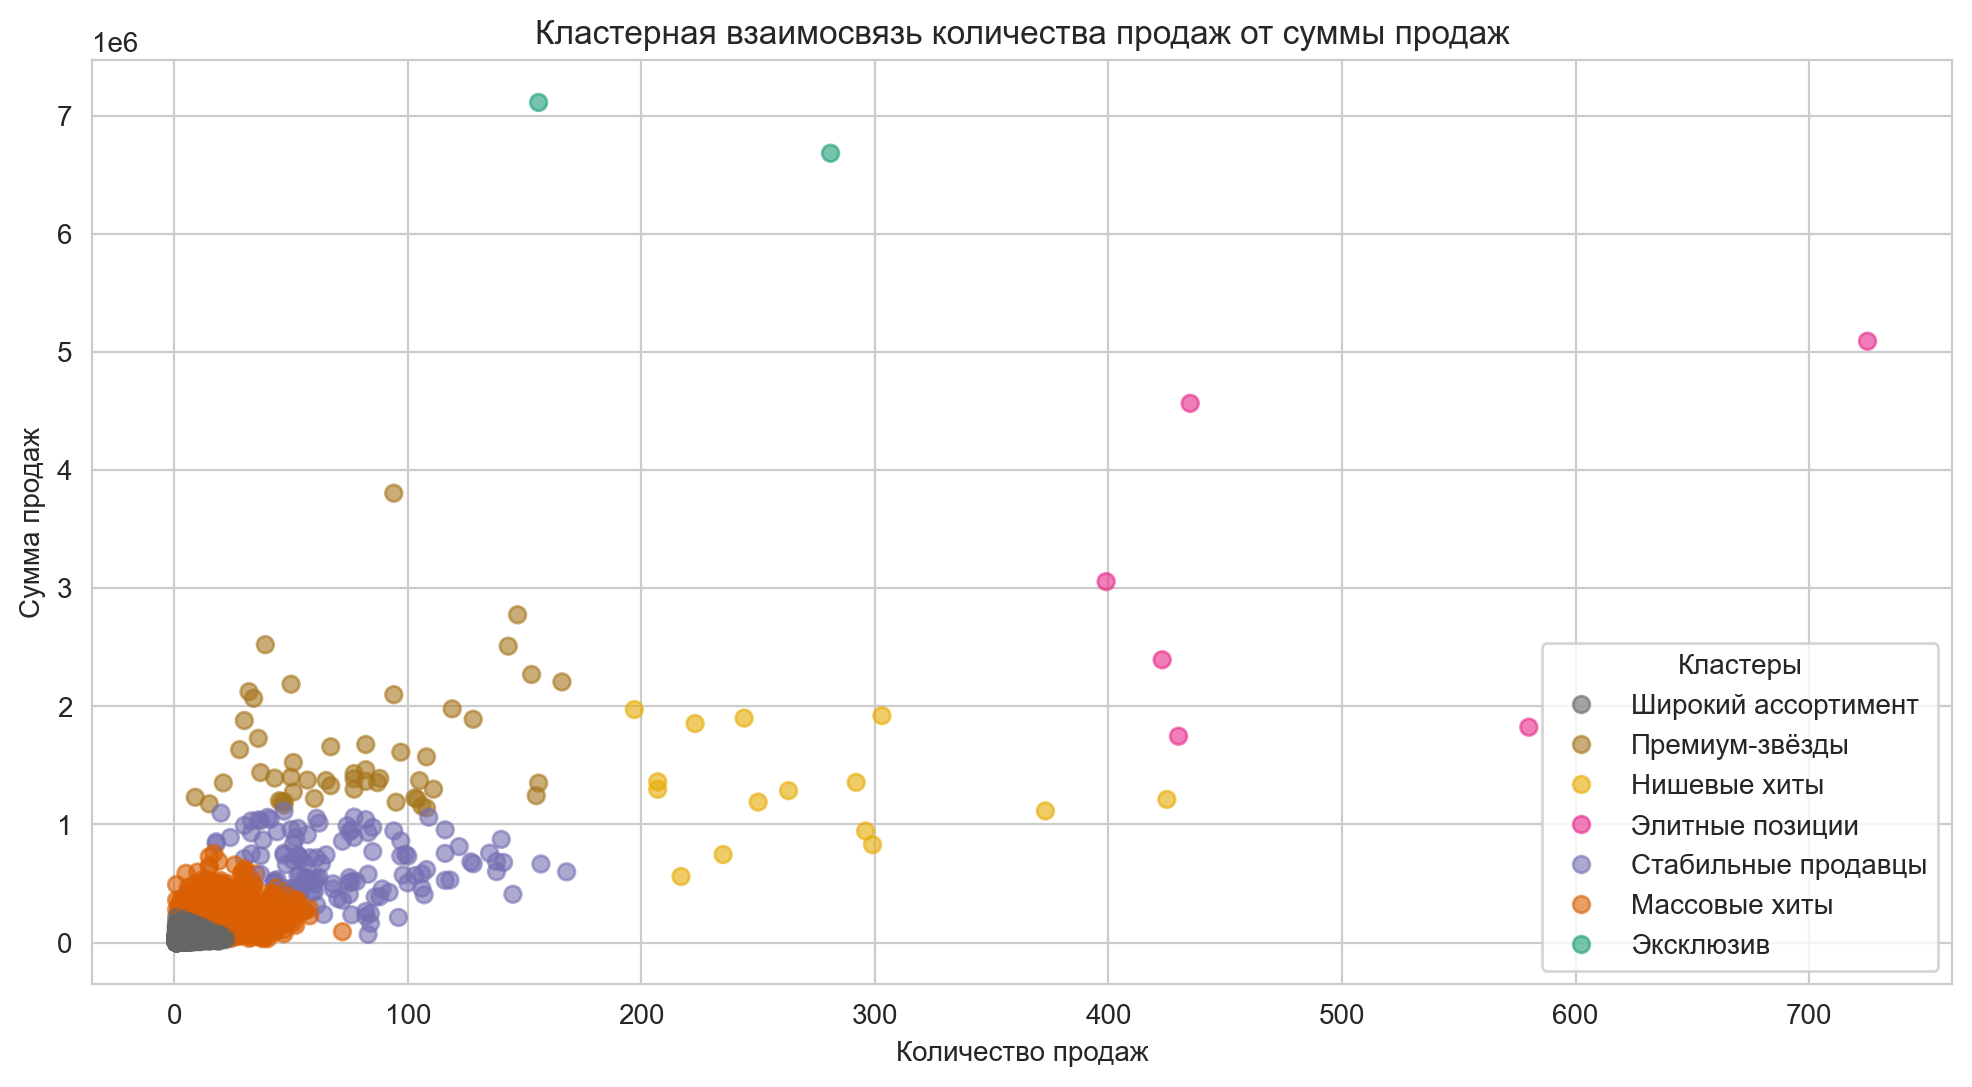

In [66]:
# визуализация результатов кластеризации: график рассеяния - зависимость количества продаж от суммы продаж
# зависимость количества от продаж (суммы)
scatter = plt.scatter(dfsum['Количество'], dfsum['Сумма'], c=kmeans.labels_, cmap='Dark2_r', alpha=0.6)
plt.xlabel('Количество продаж')
plt.ylabel('Сумма продаж')
plt.title('Кластерная взаимосвязь количества продаж от суммы продаж', fontsize=12)

# определяем названия в порядке меток
cluster_names = [
    'Широкий ассортимент',   # Кластер 0
    'Премиум-звёзды',        # Кластер 1
    'Нишевые хиты',          # Кластер 2
    'Элитные позиции',       # Кластер 3
    'Стабильные продавцы',   # Кластер 4
    'Массовые хиты',         # Кластер 5
    'Эксклюзив'              # Кластер 6
]

plt.legend(handles=scatter.legend_elements()[0], labels=cluster_names, title="Кластеры", loc="lower right")

plt.show()

На этом графике мы видим, как товары сгруппировались по двум ключевым бизнес-метрикам: 1) насколько часто покупают товар (количество) и 2) сколько денег он приносит (сумма). Поскольку кластеризация проводилась по 4 признакам (включая доли), но визуализируются только 2, график — это проекция многомерных кластеров на плоскость «Количество × Сумма». Товары с низкими значением количества продаж и с низкой выручкой создают очень плотную область внизу слева, это явные аутсайдеры. Вверху слева могли бы быть товары с высокой выручкой, но низким колчиеством продаж и это был бы премиум-сегмент, но на графике в этой области пустое пространствео, не отмеченное точками. Вверху справа и вверху по центру есть незначительно количество точек зелёного и розового цвета, характерные для кластеров 3 `Элитные позиции` и  6 `Эксклюзив `. Это товары с высоким количеством продаж и свысокой выручкой, свеого рода хиты. 
<br>Исходя из визуальных данных, мы можем говорить о том, что алгоритм `K-means`хорошо сегментировал товары в этой плоскости и на графике отображены чёткие, непересекающиеся облаака.

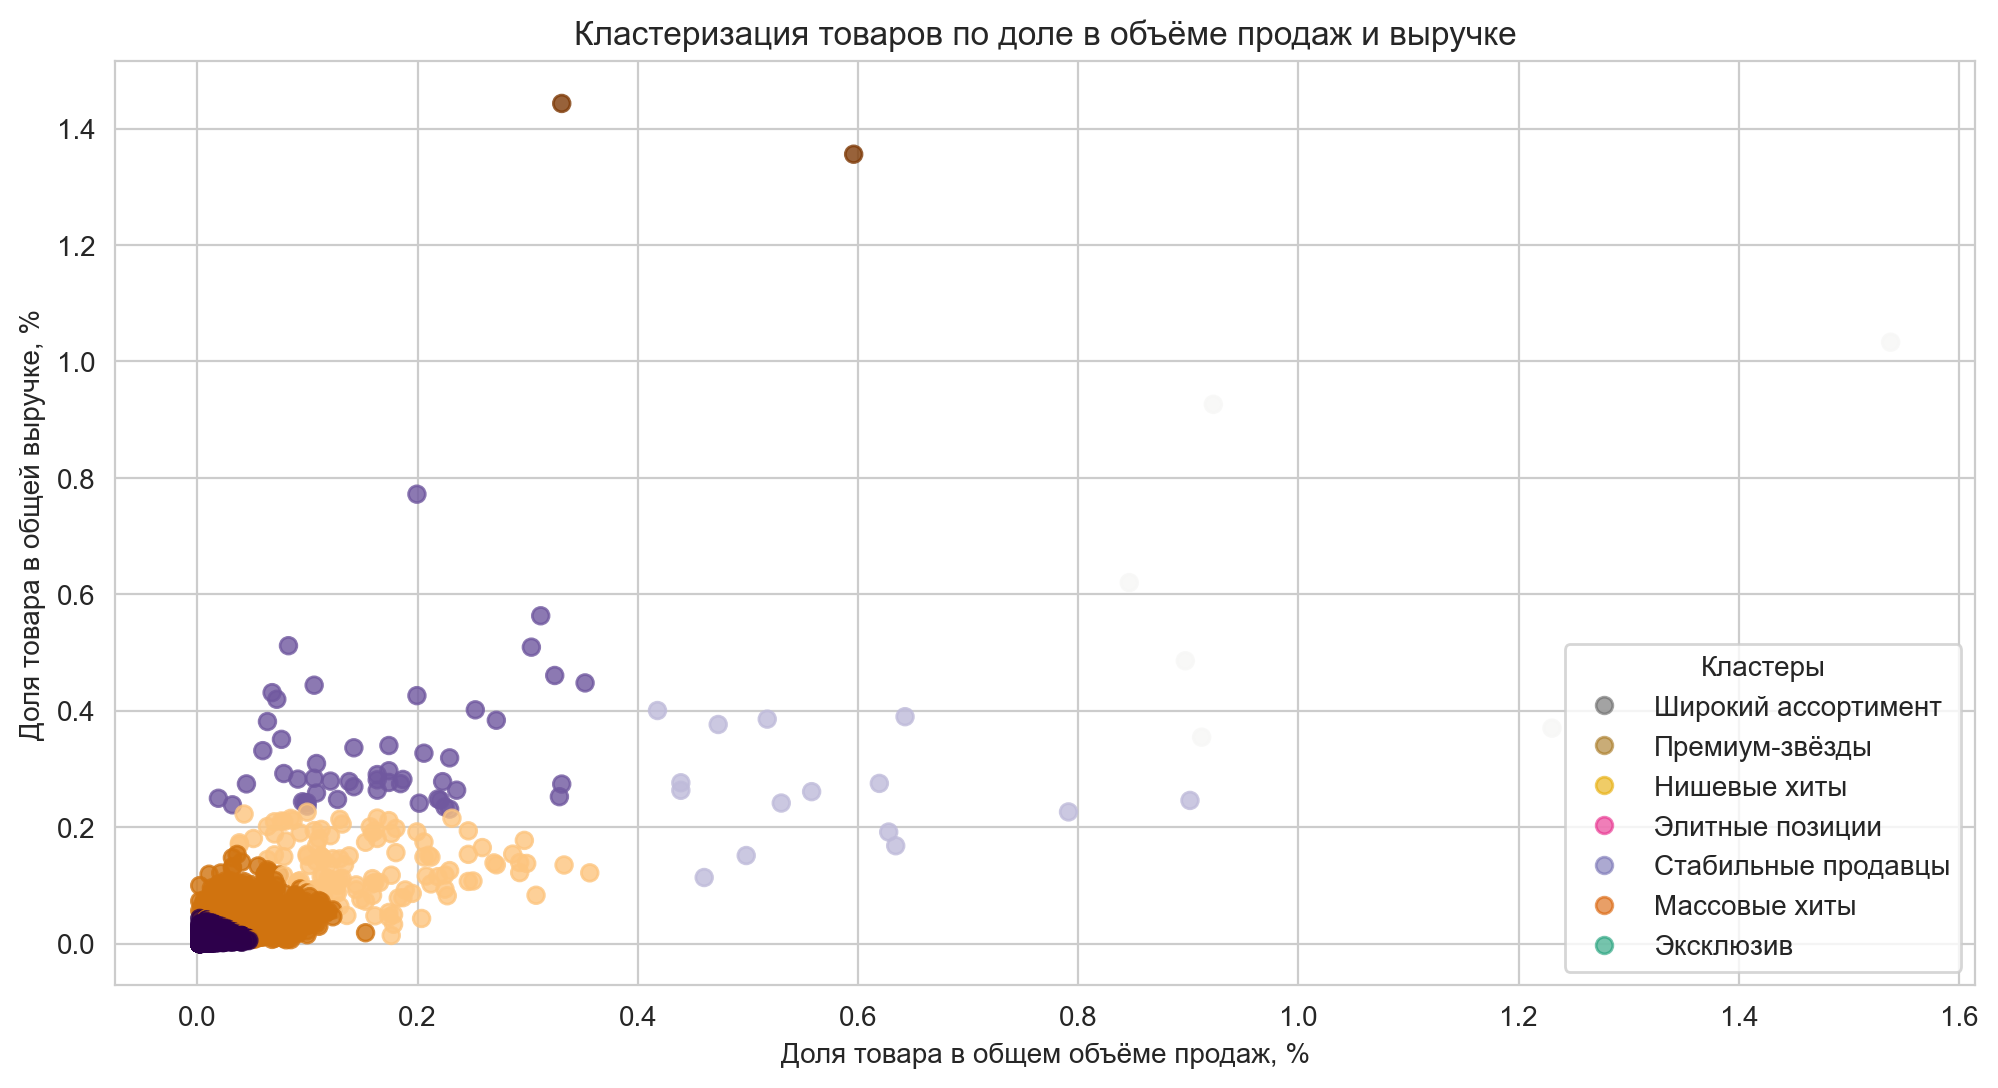

In [67]:
# кластеризация: второй график рассеяния - зависимость объёма продаж от суммарного количества
# зависимость новых признаков от суммарного количества
plt.scatter(dfsum['Доля от количества товаров'], dfsum['Доля от суммы продаж'], c=kmeans.labels_, cmap='PuOr_r', alpha=0.8)
plt.xlabel('Доля товара в общем объёме продаж, %')
plt.ylabel('Доля товара в общей выручке, %')
plt.title('Кластеризация товаров по доле в объёме продаж и выручке')

# определяем названия в порядке меток
cluster_names = [
    'Широкий ассортимент',   # Кластер 0
    'Премиум-звёзды',        # Кластер 1
    'Нишевые хиты',          # Кластер 2
    'Элитные позиции',       # Кластер 3
    'Стабильные продавцы',   # Кластер 4
    'Массовые хиты',         # Кластер 5
    'Эксклюзив'              # Кластер 6
]

plt.legend(handles=scatter.legend_elements()[0], labels=cluster_names, title="Кластеры", loc="lower right")
plt.show()

На этой точечной диаграмме показана связь между двумя относительными процентными метриками для каждого товара: по оси `х` - доля от количества товаров, то есть какой процент от общего числа проданных единиц приходится на данный товар (это объём вклада товара в общие продажи по штукам), по оси `y` - доля от суммы продаж — какой процент от общей выручки приходится на данный товар (это вклад товара в общую выручку). Хорошо представлена группа `стабильные продавцы`, `массовые хиты`, которые по своей прибыльности показывают хорошие устойчивые результаты.

<a id=5.2.></a>
### Шаг 5.2. Установление важных признаков

In [68]:
# применим критерий chi2 для оценки связи признаков
X = dfsum[['Товар', 'Количество', 'Сумма', 'Доля от суммы продаж', 'Доля от количества товаров']]
y = dfsum.iloc[:, 2]

bestfeatures = SelectKBest(score_func=chi2, k='all')
fit = bestfeatures.fit(X, y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Признак', 'Оценка']
featureScores['Оценка'].astype(int)
featureScores.sort_values(by='Оценка', ascending=False)

,Признак,Оценка
2,Сумма,4.316482e+09
0,Товар,4.000597e+06
1,Количество,4.471470e+05
4,Доля от количества товаров,9.484304e+02
3,Доля от суммы продаж,8.756929e+02


**Вывод:** для выделения важных признаков используем метод фильтрации данных SelectKBest, который оценивает взаимосвязь предикторов с целевой переменной «Сумма», используя статистический тест хи-квадрат. Это позволит отобрать наилучшие по заданному критерию признаки. Из полученных результатов мы можем сделать вывод, что «Количество» является лучшим признаком для целевой переменной «Сумма».

<a id=5.3.></a>
### Шаг 5.3. Построение рекомендательной системы

In [69]:
# создадим сводную таблицу, на основе которой будем строить рекомендательную систему
all_user_items = df[['Товар', 'Клиент', 'Количество']].groupby(['Товар', 'Клиент']).sum().sort_values('Количество', ascending=False).reset_index()
all_user_items.head()

,Товар,Клиент,Количество
0,2602,4997,21
1,5302,22,19
2,2519,1572,14
3,5305,1323,14
4,1789,3738,13


In [70]:
# преобразование содержимого в векторы
# создадим сводную таблицу, где столбцы - это товары, строки - это пользователи
# на пересечении столбца и строки - клиент купил / не купил этот товар
# на основании этой таблицы можно построить рейтинг - сколько этот пользователь купил этого товара
# заполняем NaN нулевыми значениями
df_matrix = pd.pivot_table(all_user_items, values='Количество', index='Клиент', columns='Товар').fillna(0) 
df_matrix.head()

Товар,1,2,3,4,5,6,7,8,9,10,...,5514,5515,5516,5517,5518,5519,5520,5521,5522,5523
Клиент,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [71]:
# уменьшение размерности матрицы
print('Матрица для построения рекомендательной системы имеет размер', df_matrix.shape[0], 'строк на', df_matrix.shape[1], 'столбцов. Уменьшения размерности матрицы для дальнейшей работы не требуется.')

Матрица для построения рекомендательной системы имеет размер 10989 строк на 5293 столбцов. Уменьшения размерности матрицы для дальнейшей работы не требуется.


In [72]:
# с помощью метода ближайших соседей определяем размерность близости через косинус
knn = NearestNeighbors(n_neighbors=10, algorithm='brute', metric='cosine')
model_knn = knn.fit(df_matrix)

In [73]:
# находим других покупателей с ненулевым коэффициентом подобия:
def most_similar_users_to(user_id):
    most_similar_users_to = []
    distance, indice = model_knn.kneighbors(df_matrix.iloc[user_id,:].values.reshape(1,-1), n_neighbors=10)
    for i in range(1, len(distance.flatten())):
        user_id1 = df_matrix.index[indice.flatten()[i]]
        most_similar_users_to.append((user_id1, distance.flatten()[i]))

# сортируем найденные топ-10 других покупателей с ненулевым коэффициентом подобия:
    most_similar_users_to.sort(key=lambda x: x[1], reverse=True)
    return most_similar_users_to[:10]  

In [74]:
# выводим топ-10 покупателей с наибольшим подобием:
print('Рекомендации для покупателя на основе подобия интересов других покупателей: ', most_similar_users_to(36))

Рекомендации для покупателя на основе подобия интересов других покупателей:  [(np.int64(11037), np.float64(1.0)), (np.int64(11036), np.float64(1.0)), (np.int64(11035), np.float64(1.0)), (np.int64(11034), np.float64(1.0)), (np.int64(11033), np.float64(1.0)), (np.int64(11032), np.float64(1.0)), (np.int64(11031), np.float64(1.0)), (np.int64(160), np.float64(0.8492443277111181)), (np.int64(111), np.float64(0.6220355269907728))]


In [75]:
# рекомендация на основе предпочтений покупателя:
def user_based_suggestions(user_id):
    # суммируем все коэффициенты подобия
    suggestions = defaultdict(float)
    new_items_to_buy = df_matrix.iloc[user_id][df_matrix.iloc[user_id] == 0].index.tolist()
    for other_user_id, similarity in most_similar_users_to(user_id):
        items_user_id = df_matrix.loc[other_user_id][df_matrix.loc[other_user_id] > 0]
        for interest in items_user_id.index.tolist():
            if interest in new_items_to_buy:
                suggestions[interest] += similarity

# преобразуем все коэффициенты подобия в сортированный список
    suggestions = sorted(suggestions.items(), key=lambda x: x[1], reverse=True)
    return suggestions[:10]

In [76]:
# выводим топ-10 предложений на основе рейтинга покупателя:
print('Рекомендации для покупателя на основе его интересов: ', user_based_suggestions(36))

Рекомендации для покупателя на основе его интересов:  [(198, np.float64(1.0)), (3516, np.float64(1.0)), (3296, np.float64(1.0)), (5017, np.float64(1.0)), (4944, np.float64(1.0)), (2056, np.float64(1.0)), (2164, np.float64(1.0)), (2833, np.float64(1.0)), (1758, np.float64(1.0)), (244, np.float64(1.0))]


<a id=6></a>
## Шаг 6. Вывод

<br>В рамках данного аналитического проекта была проведена всесторонняя оценка деятельности торгового объекта на основе транзакционных данных за период с 1 мая 2020 года по 12 июля 2021 года. Целью исследования стало не только описание текущей ситуации, но и выявление ключевых драйверов выручки, сегментация клиентской базы, определение структуры ассортимента и разработка основ для персонализированной рекомендательной системы. Проект реализован в строгой методологической последовательности: от предварительной обработки данных через разведочный анализ и RFM-сегментацию до кластеризации и построения рекомендаций на основе машинного обучения.
<br><br>На этапе предварительной обработки удалось качественно подготовить данные к анализу: были устранены пропущенные значения (всего 30 записей, что составляет менее 0,1% от исходного объёма), удалены полные дубликаты и корректно преобразованы типы данных. В результате потери информации составили всего 2,4%, что свидетельствует о высокой сохранности исходной информации. Были также созданы производные признаки, связанные со временем и датой покупки, что позволило провести детальный временной анализ.
<br>Разведочный анализ данных выявил, что структура датасета соответствует формату «транзакция–товар», где каждый чек с несколькими позициями разбит на отдельные строки. Это подтверждается тем, что признак «Количество» везде равен 1. Всего зафиксировано 47 146 транзакций, 14 127 уникальных клиентов и 5 523 уникальных товара. Распределение сумм покупок оказалось сильно скошенным вправо: медианная сумма (6 910) значительно ниже средней (10 455), а максимальная транзакция (511 500) представляет собой явный выброс, возможно, единичную премиальную покупку. Это типичная картина для розничной торговли — преобладание недорогих покупок при наличии редких, но высокомаржинальных транзакций.
<br><br>Особое внимание было уделено анализу выручки по ценовым сегментам. Было установлено, что менее 18% транзакций (все покупки свыше 12 750) генерируют почти 60% общей выручки. Наиболее прибыльный сегмент (21 751–511 500) обеспечивает 35,8% дохода при доле всего ~10% от общего числа покупок. Это указывает на критическую важность высокочековых клиентов и товаров — небольшая группа транзакций оказывает непропорционально большое влияние на финансовый результат. При этом нижний ценовой сегмент, несмотря на высокую частоту (25% транзакций), вносит лишь 5,5% выручки, что ставит под сомнение его стратегическую ценность без дополнительных мер по монетизации.
<br><br>Анализ динамики продаж выявил чёткую сезонность: пик активности приходится на май (8 937 покупок — максимум за весь период), а также на тёплый сезон в целом (апрель–сентябрь). В холодный период (октябрь–март), особенно в ноябре (всего 1 966 покупок), наблюдается резкий спад. Примечательно, что декабрь и январь — традиционно высокие месяцы для ритейла — не демонстрируют значительного роста, что может свидетельствовать либо о специфике ассортимента (отсутствие праздничных/подарочных товаров), либо о недостаточной маркетинговой активности в этот период. В то же время график работы магазина (с 10:00 до 24:00 без выходных) и сохранение активности даже в пик пандемии говорят о высокой доступности и устойчивости бизнес-модели.
<br><br>Исследование ассортимента показало, что топ-10 товаров по выручке включает как премиальные позиции (например, ID 3060 — 7,1 млн при 156 продажах), так и массовые товары (ID 4944 — 5,1 млн при 725 продажах). Это свидетельствует о сбалансированной товарной матрице, способной обслуживать как массовую, так и премиальную аудиторию. Более того, анализ по закону Парето выявил, что всего 1 093 товара (20,7% от общего ассортимента) генерируют 80% выручки. Это открывает значительные возможности для оптимизации: исключение низкооборотных позиций (4 200 товаров, вносящих лишь 20% дохода) может снизить операционные издержки и усилить фокус на ключевых SKU.
<br><br>Временной анализ покупательской активности подтвердил социально-бытовой ритм клиентов: пик приходится на 16:00–18:00, минимальная активность — ночью и ранним утром. Это позволяет рекомендовать маркетинговые коммуникации и персонализированные предложения в интервале 15:00–16:00, чтобы «поймать» покупателя перед волной вечернего спроса.
<br><br>Корреляционный анализ не выявил сильных линейных взаимосвязей между числовыми признаками, за исключением умеренной связи между ID транзакции и ID клиента (r ≈ 0.603), что является артефактом хронологической структуры данных, а не признаком содержательной зависимости. Это указывает на необходимость использования нелинейных или категориальных методов для выявления скрытых паттернов.
<br><br>В рамках RFM-анализа клиентская база была разделена на сегменты по трём критериям: давность, частота и денежная ценность. Было установлено, что число «лучших» клиентов (989 человек) превышает число «потерянных» (933 человека), что говорит о в целом здоровом состоянии клиентской лояльности. Однако сохранение и развитие отношений с высокочековыми клиентами должно стать приоритетом, поскольку именно они обеспечивают львиную долю дохода.
<br><br>На этапе кластеризации товаров с использованием метода K-means было выделено 5 устойчивых сегментов на основе признаков «Количество», «Сумма», «Доля в выручке» и «Доля в объёме продаж». Это позволяет более гибко подходить к управлению ассортиментом, ценообразованию и продвижению. Для построения рекомендательной системы был применён алгоритм KNN (`NearestNeighbors`) на основе бинарной матрицы «пользователь–товар». Предварительный отбор признаков с использованием критерия хи-квадрат показал, что признак «Количество» (в данном случае — факт покупки) является наиболее информативным для прогнозирования интереса к товару. Система способна генерировать персонализированные рекомендации, основанные как на поведении схожих пользователей, так и на индивидуальной истории покупок.

<br>Подводя итоги вышесказанному, торговый объект демонстрирует устойчивую, но сезонно зависимую бизнес-модель с выраженным фокусом на высокомаржинальные продажи. Ключевая ценность бизнеса сосредоточена в небольшой группе премиальных товаров и клиентов, чьи транзакции, несмотря на низкую частоту, генерируют основную часть выручки. При этом массовый сегмент обеспечивает стабильный поток трафика и поддерживает ликвидность ассортимента. Для дальнейшего роста критически важны три направления:  
1. Удержание и углубление отношений с VIP-клиентами через персонализированные предложения, эксклюзивный сервис и программы лояльности;
2. Оптимизация ассортимента — сокращение «хвоста» низкооборотных товаров и усиление фокуса на 20% SKU, обеспечивающих 80% дохода;  
3. Активизация низкосезонных периодов, особенно ноября–декабря, через введение праздничных категорий и целевые маркетинговые кампании.

Разработанная рекомендательная система и сегментация клиентов/товаров создают прочную аналитическую основу для реализации этих стратегий. Проект успешно достиг своей цели: от описания данных к инсайтам, напрямую влияющим на рост выручки и укрепление клиентской лояльности.
<br>
<br>**На основании вышеизложенного, в рамках реализации итоговой работы был проведён детальный анализ предложенного датасета. В ходе работы была осуществлена предварительная обработка данных, проведены исследования признаков. В результате данные были сегментированы и представлены графически, а на их основе разработаны оптимальные рекомендации.**